# Đồ án Tiền xử lý dữ liệu - Phần 2: Phương pháp & EDA  
*Tập dữ liệu: Rain in Australia*  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
# Load dữ liệu (Kaggle version: 145,460 rows × 23 cols)
df = pd.read_csv('data/weatherAUS.csv')

# Parse cột Date thành datetime
df['Date'] = pd.to_datetime(df['Date'])

# Xem thông tin cơ bản
print(f'Kích thước tập dữ liệu: {df.shape}')
df.head()

Kích thước tập dữ liệu: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 2.2.1 EDA Sơ bộ (Preliminary EDA)

Khảo sát tổng quan tập dữ liệu trước khi đi vào phân tích chuyên sâu, gồm ba góc nhìn:
1. **Thuộc tính số** — thống kê mô tả (mean, std, min/max, quartiles)
2. **Thuộc tính phân loại** — số lớp, tần suất, cardinality
3. **Giá trị thiếu** — tỷ lệ NA theo từng cột

A. TỔNG QUAN CẤU TRÚC DỮ LIỆU
  Số mẫu  : 145,460
  Số cột  : 23

  Thuộc tính số        (16 cột): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
  Thuộc tính phân loại ( 6 cột): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
  Thuộc tính datetime  ( 1 cột): ['Date']

B. THUỘC TÍNH SỐ — Thống kê mô tả
                  count     mean    std    min     25%     50%     75%     max  missing_count  missing_pct
Thuộc tính                                                                                                
MinTemp        143975.0    12.19   6.40   -8.5     7.6    12.0    16.9    33.9           1485         1.02
MaxTemp        144199.0    23.22   7.12   -4.8    17.9    22.6    28.2    48.1           1261         0.87
Rainfall       142199.0     2.36   8.48    0.0     0.0     0.

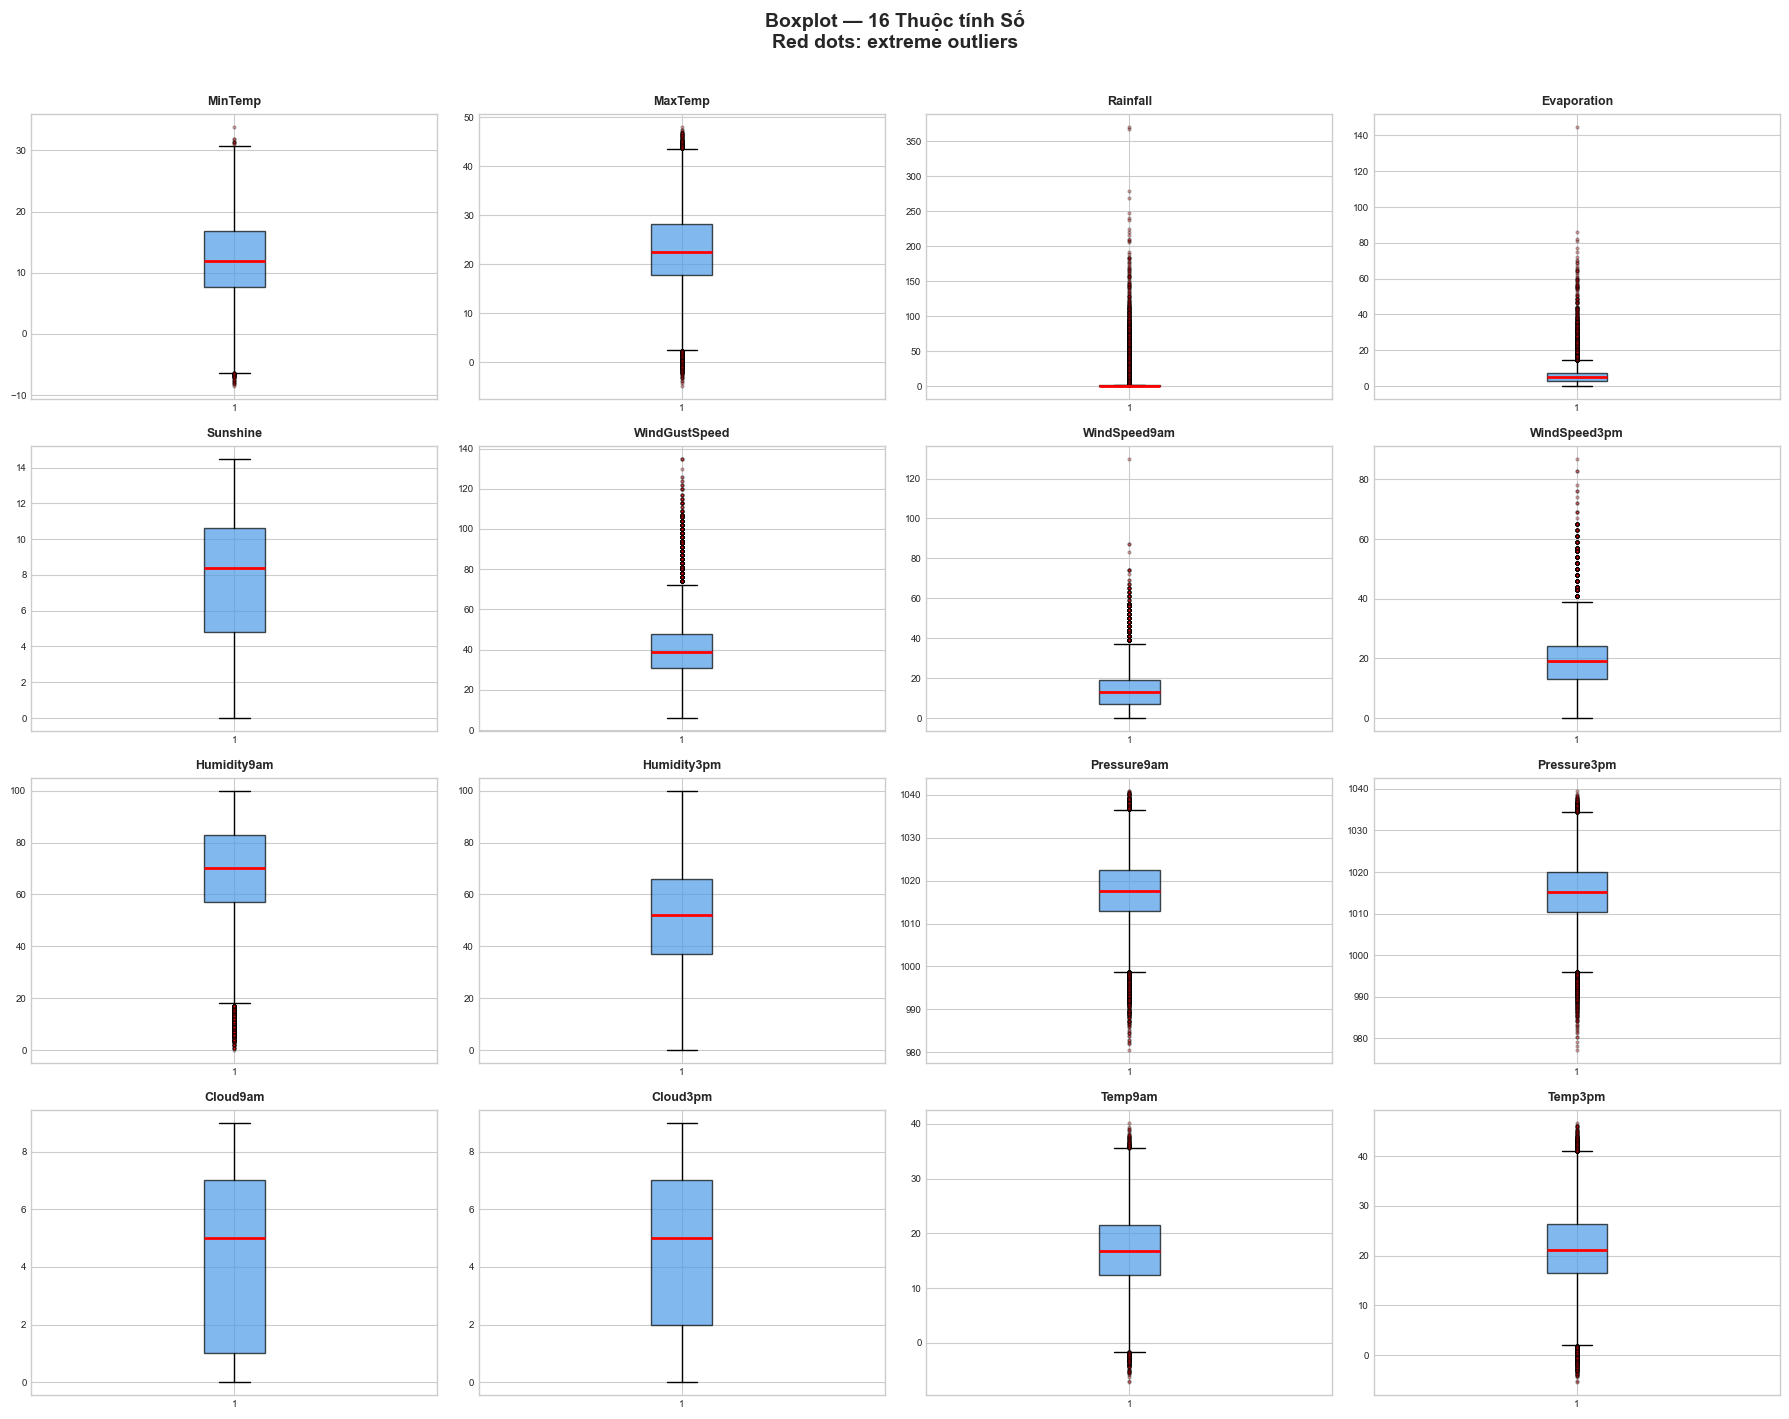


C. THUỘC TÍNH PHÂN LOẠI — Cardinality & Tần suất
              Cardinality Top value  Top freq  Top %  Missing Missing %
Thuộc tính                                                             
Location               49  Canberra      3436   2.4%        0     0.00%
WindGustDir            16         W      9915   7.3%    10326     7.10%
WindDir9am             16         N     11758   8.7%    10566     7.26%
WindDir3pm             16        SE     10838   7.7%     4228     2.91%
RainToday               2        No    110319  77.6%     3261     2.24%
RainTomorrow            2        No    110316  77.6%     3267     2.25%


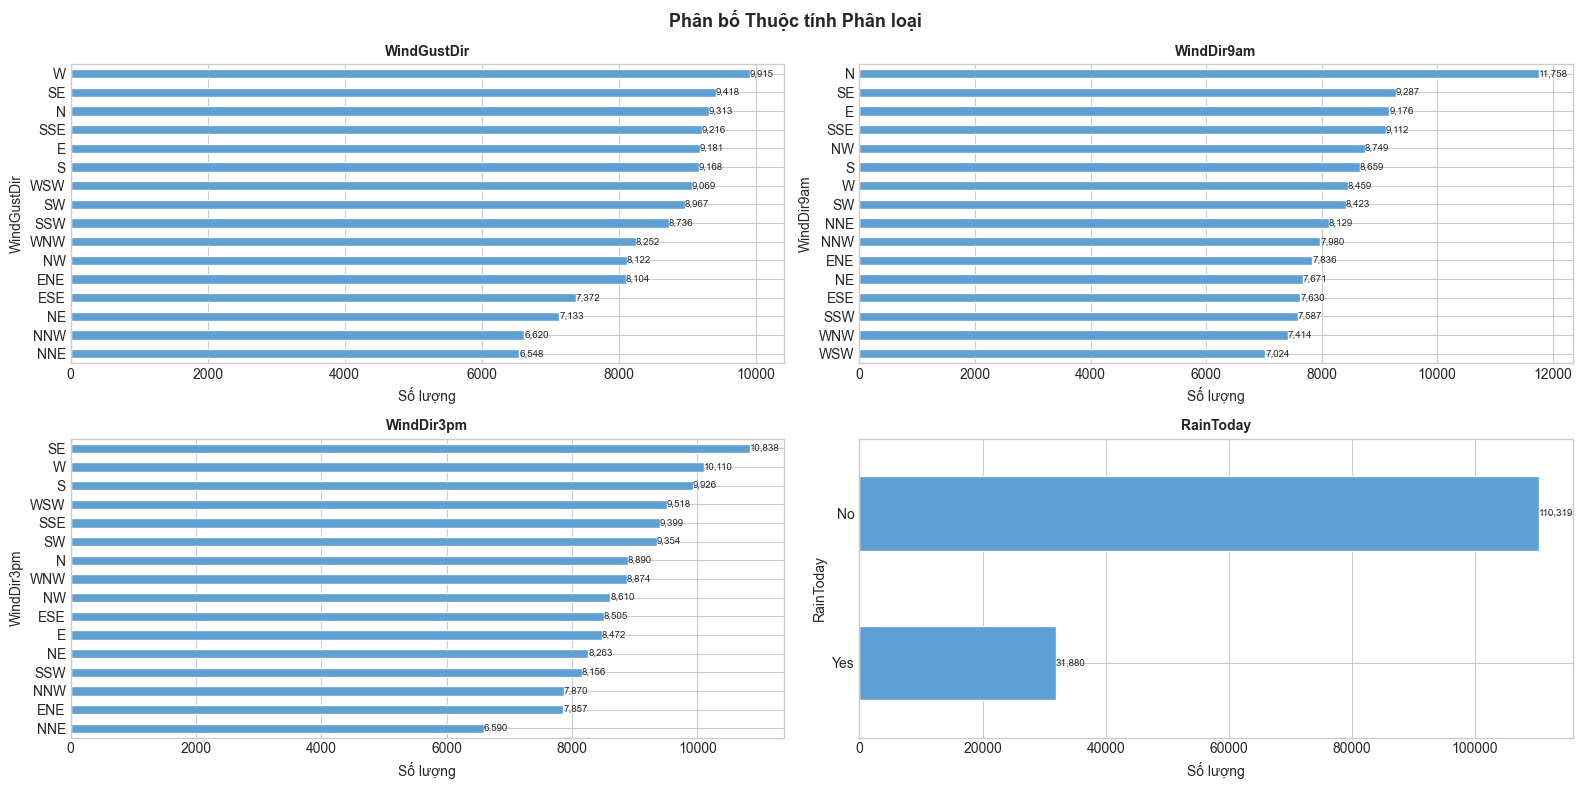

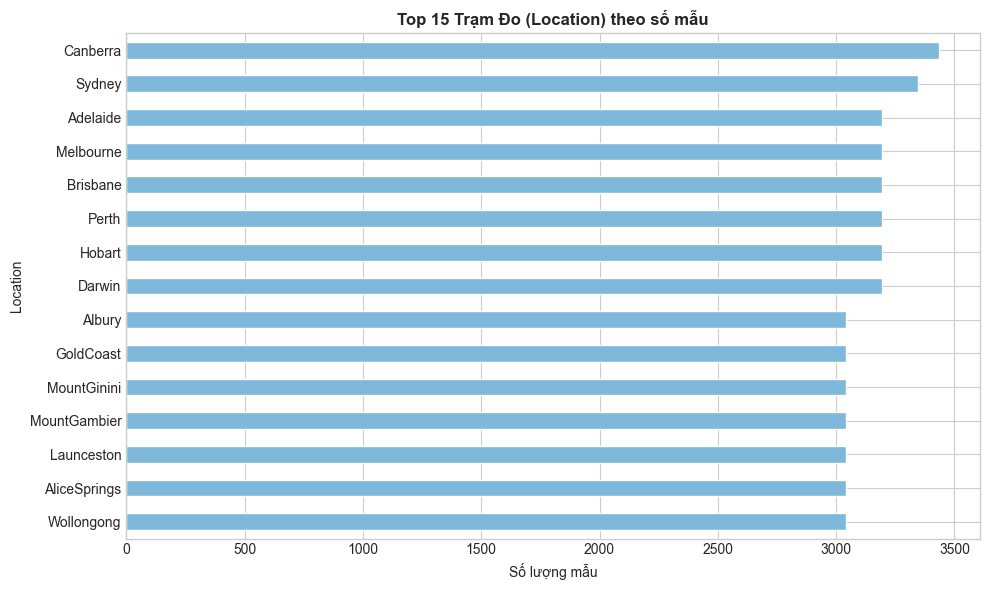


D. GIÁ TRỊ THIẾU — Tổng quan
Tổng cột có missing: 21/22
Tổng ô missing      : 343,248
Tỷ lệ missing tổng  : 10.73%

               Missing Count  Missing %              Mức độ
Sunshine               69835      48.01        Cao (20–50%)
Evaporation            62790      43.17        Cao (20–50%)
Cloud3pm               59358      40.81        Cao (20–50%)
Cloud9am               55888      38.42        Cao (20–50%)
Pressure9am            15065      10.36  Trung bình (5–20%)
Pressure3pm            15028      10.33  Trung bình (5–20%)
WindDir9am             10566       7.26  Trung bình (5–20%)
WindGustDir            10326       7.10  Trung bình (5–20%)
WindGustSpeed          10263       7.06  Trung bình (5–20%)
Humidity3pm             4507       3.10          Thấp (<5%)
WindDir3pm              4228       2.91          Thấp (<5%)
Temp3pm                 3609       2.48          Thấp (<5%)
RainTomorrow            3267       2.25          Thấp (<5%)
Rainfall                3261       2.24    

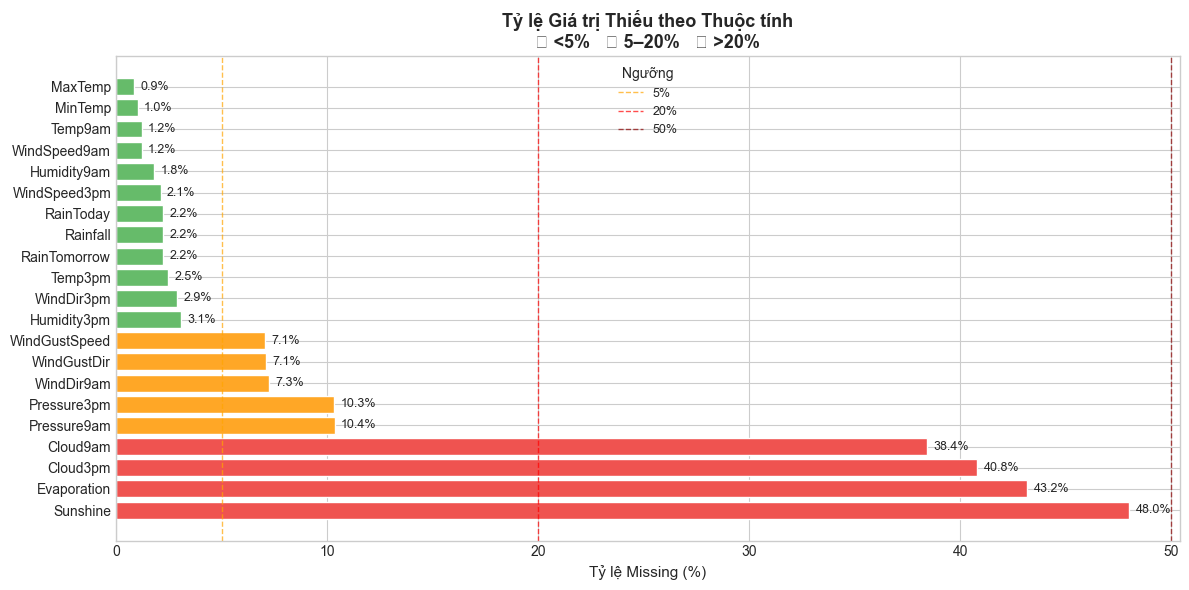

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ═══════════════════════════════════════════════════════════════
# A. TỔNG QUAN CẤU TRÚC DỮ LIỆU
# ═══════════════════════════════════════════════════════════════
print("=" * 60)
print("A. TỔNG QUAN CẤU TRÚC DỮ LIỆU")
print("=" * 60)
print(f"  Số mẫu  : {len(df):,}")
print(f"  Số cột  : {df.shape[1]}")
print()

# Phân loại cột theo dtype
num_cols  = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols  = df.select_dtypes(include=['object', 'bool']).columns.tolist()
date_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns.tolist()
# Loại RainTomorrow khỏi cat_cols để dùng riêng (target)
feature_cat = [c for c in cat_cols if c not in ['RainTomorrow']]

print(f"  Thuộc tính số        ({len(num_cols):2d} cột): {num_cols}")
print(f"  Thuộc tính phân loại ({len(cat_cols):2d} cột): {cat_cols}")
print(f"  Thuộc tính datetime  ({len(date_cols):2d} cột): {date_cols}")
print()

# ═══════════════════════════════════════════════════════════════
# B. EDA THUỘC TÍNH SỐ
# ═══════════════════════════════════════════════════════════════
print("=" * 60)
print("B. THUỘC TÍNH SỐ — Thống kê mô tả")
print("=" * 60)
desc = df[num_cols].describe().T.round(2)
desc['missing_count'] = df[num_cols].isnull().sum()
desc['missing_pct']   = (df[num_cols].isnull().mean() * 100).round(2)
desc.index.name = 'Thuộc tính'
print(desc[['count','mean','std','min','25%','50%','75%','max','missing_count','missing_pct']].to_string())

# Boxplots cho thuộc tính số
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle('Boxplot — 16 Thuộc tính Số\nRed dots: extreme outliers', fontsize=14, fontweight='bold', y=1.01)
for ax, col in zip(axes.flatten(), num_cols):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C9BE8', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════
# C. EDA THUỘC TÍNH PHÂN LOẠI
# ═══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("C. THUỘC TÍNH PHÂN LOẠI — Cardinality & Tần suất")
print("=" * 60)

cat_summary = []
for col in cat_cols:
    n_unique  = df[col].nunique()
    top_val   = df[col].value_counts().idxmax() if df[col].notna().any() else 'N/A'
    top_freq  = df[col].value_counts().max()    if df[col].notna().any() else 0
    top_pct   = top_freq / df[col].notna().sum() * 100
    n_missing = df[col].isnull().sum()
    cat_summary.append({
        'Thuộc tính': col,
        'Cardinality': n_unique,
        'Top value': str(top_val),
        'Top freq': top_freq,
        'Top %': f'{top_pct:.1f}%',
        'Missing': n_missing,
        'Missing %': f'{n_missing/len(df)*100:.2f}%'
    })

cat_df = pd.DataFrame(cat_summary).set_index('Thuộc tính')
print(cat_df.to_string())

# Bar charts cho các cột phân loại (trừ Location và Date)
plot_cats = [c for c in feature_cat if c not in ['Location', 'Date']]
n_plot = len(plot_cats)
fig, axes = plt.subplots(2, (n_plot + 1) // 2, figsize=(16, 8))
fig.suptitle('Phân bố Thuộc tính Phân loại', fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(plot_cats):
    vc = df[col].value_counts().sort_values(ascending=True)
    vc.plot(kind='barh', ax=axes_flat[i], color='#5E9FD4', edgecolor='white')
    axes_flat[i].set_title(col, fontsize=10, fontweight='bold')
    axes_flat[i].set_xlabel('Số lượng')
    for p in axes_flat[i].patches:
        axes_flat[i].annotate(f'{p.get_width():,.0f}',
                              (p.get_width(), p.get_y() + p.get_height() / 2),
                              ha='left', va='center', fontsize=7)

# Ẩn axes thừa
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.tight_layout()
plt.show()

# Location: top 15 stations
fig, ax = plt.subplots(figsize=(10, 6))
df['Location'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=ax, color='#7EB8DA', edgecolor='white')
ax.set_title('Top 15 Trạm Đo (Location) theo số mẫu', fontsize=12, fontweight='bold')
ax.set_xlabel('Số lượng mẫu')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════
# D. EDA GIÁ TRỊ THIẾU (MISSING VALUES)
# ═══════════════════════════════════════════════════════════════
print()
print("=" * 60)
print("D. GIÁ TRỊ THIẾU — Tổng quan")
print("=" * 60)

miss_df = pd.DataFrame({
    'Missing Count': df.drop(columns=['Date']).isnull().sum(),
    'Missing %'    : (df.drop(columns=['Date']).isnull().mean() * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
miss_df['Mức độ'] = pd.cut(miss_df['Missing %'],
                            bins=[-1, 5, 20, 50, 100],
                            labels=['Thấp (<5%)', 'Trung bình (5–20%)',
                                    'Cao (20–50%)', 'Rất cao (>50%)'])
print(f"Tổng cột có missing: {len(miss_df)}/{df.shape[1]-1}")
print(f"Tổng ô missing      : {df.drop(columns=['Date']).isnull().sum().sum():,}")
print(f"Tỷ lệ missing tổng  : {df.drop(columns=['Date']).isnull().mean().mean()*100:.2f}%")
print()
print(miss_df.to_string())

# Bar chart missing values
fig, ax = plt.subplots(figsize=(12, 6))
colors = miss_df['Missing %'].apply(
    lambda x: '#EF5350' if x > 20 else ('#FFA726' if x > 5 else '#66BB6A'))
bars = ax.barh(miss_df.index, miss_df['Missing %'], color=colors.values, edgecolor='white')
ax.set_xlabel('Tỷ lệ Missing (%)', fontsize=11)
ax.set_title('Tỷ lệ Giá trị Thiếu theo Thuộc tính\n'
             '🟢 <5%   🟠 5–20%   🔴 >20%', fontsize=13, fontweight='bold')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1, alpha=0.7, label='5%')
ax.axvline(20, color='red',    linestyle='--', linewidth=1, alpha=0.7, label='20%')
ax.axvline(50, color='darkred',linestyle='--', linewidth=1, alpha=0.7, label='50%')
for bar, pct in zip(bars, miss_df['Missing %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.legend(title='Ngưỡng', fontsize=9)
plt.tight_layout()
plt.show()


## 2.2.2 Phân tích thống kê khám phá (EDA chuyên sâu)

### a) Kiểm tra phân phối các thuộc tính số

**Phương pháp kiểm tra phân phối chuẩn:**

Do $n = 145{,}460 > 5{,}000$, ta dùng **D'Agostino-Pearson test** (`scipy.stats.normaltest`) thay vì Shapiro-Wilk (chỉ phù hợp $n \leq 5{,}000$).

**Công thức D'Agostino-Pearson (omnibus test):**

$$K^2 = Z_1^2(\text{skewness}) + Z_2^2(\text{kurtosis})$$

- $K^2$ tuân theo phân phối $\chi^2$ với 2 bậc tự do.
- $H_0$: Dữ liệu có phân phối chuẩn. Bác bỏ nếu $p < \alpha = 0.05$.

---

**Skewness (Độ lệch)** — đo tính đối xứng:

$$\gamma_1 = \frac{m_3}{m_2^{3/2}} = \frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^3}{\left[\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2\right]^{3/2}}$$

- $\gamma_1 = 0$: đối xứng (chuẩn) | $\gamma_1 > 0$: lệch phải (đuôi dài bên phải) | $\gamma_1 < 0$: lệch trái.

**Kurtosis (Độ nhọn)** — đo mức độ "đuôi nặng":

$$\gamma_2 = \frac{m_4}{m_2^2} - 3$$

- $\gamma_2 = 0$: mesokurtic (chuẩn) | $\gamma_2 > 0$: leptokurtic (nhọn, đuôi nặng) | $\gamma_2 < 0$: platykurtic (tẹt, đuôi nhẹ).

---

**Biểu đồ trực quan hóa:**

- **Histogram + KDE**: So sánh mật độ thực tế (KDE, xanh đậm) với đường cong chuẩn lý thuyết $\mathcal{N}(\mu, \sigma^2)$ (đỏ nét đứt).
  - KDE (Kernel Density Estimation): $\hat{f}(x) = \frac{1}{nh}\sum_{i=1}^{n}K\left(\frac{x - x_i}{h}\right)$ với $K$ là Gaussian kernel.
- **QQ-plot**: Vẽ quantile mẫu vs quantile lý thuyết. Điểm bám sát đường thẳng → gần chuẩn.

In [4]:
from scipy import stats

# n = 145 460 > 5 000  →  dùng D'Agostino-Pearson (normaltest)
# Shapiro-Wilk chỉ áp dụng khi n ≤ 5 000 (tốc độ O(n²))
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'RainTomorrow']
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"n = {len(df):,}  >  5 000  →  D'Agostino-Pearson test (stats.normaltest)")
print("H₀: Dữ liệu có phân phối chuẩn  |  α = 0.05\n")

dist_records = []
for col in numerical_cols:
    data = df[col].dropna()
    k2, p = stats.normaltest(data)
    skew = float(stats.skew(data))
    kurt = float(stats.kurtosis(data))
    label = 'Chuẩn' if p > 0.05 else 'Không chuẩn'
    dist_records.append({
        'Thuộc tính':   col,
        'n_valid':      len(data),
        'K²-stat':      round(k2, 2),
        'p-value':      f'{p:.2e}',
        'Skewness':     round(skew, 3),
        'Kurtosis':     round(kurt, 3),
        'Phân phối':    label,
    })

dist_df = pd.DataFrame(dist_records)
dist_df.index = range(1, len(dist_df) + 1)
print(dist_df.to_string())

n_normal = (dist_df['Phân phối'] == 'Chuẩn').sum()
print(f"\n→ Kết quả: {n_normal}/{len(dist_df)} thuộc tính phân phối chuẩn, "
      f"{len(dist_df)-n_normal}/{len(dist_df)} KHÔNG phân phối chuẩn")
print("→ Hệ quả: Ưu tiên RobustScaler / MinMaxScaler, tránh Z-score thuần túy")

n = 145,460  >  5 000  →  D'Agostino-Pearson test (stats.normaltest)
H₀: Dữ liệu có phân phối chuẩn  |  α = 0.05

       Thuộc tính  n_valid    K²-stat    p-value  Skewness  Kurtosis    Phân phối
1         MinTemp   143975    2535.52   0.00e+00     0.021    -0.484  Không chuẩn
2         MaxTemp   144199    1531.21   0.00e+00     0.221    -0.225  Không chuẩn
3        Rainfall   142199  221624.38   0.00e+00     9.836   178.146  Không chuẩn
4     Evaporation    82670   72326.58   0.00e+00     3.761    45.040  Không chuẩn
5        Sunshine    75625   10183.27   0.00e+00    -0.496    -0.829  Không chuẩn
6   WindGustSpeed   135197   17175.70   0.00e+00     0.875     1.419  Không chuẩn
7    WindSpeed9am   143693   15125.41   0.00e+00     0.778     1.227  Không chuẩn
8    WindSpeed3pm   142398    9810.38   0.00e+00     0.628     0.764  Không chuẩn
9     Humidity9am   142806    5031.29   0.00e+00    -0.484    -0.038  Không chuẩn
10    Humidity3pm   140953    2902.77   0.00e+00     0.034    -0.5

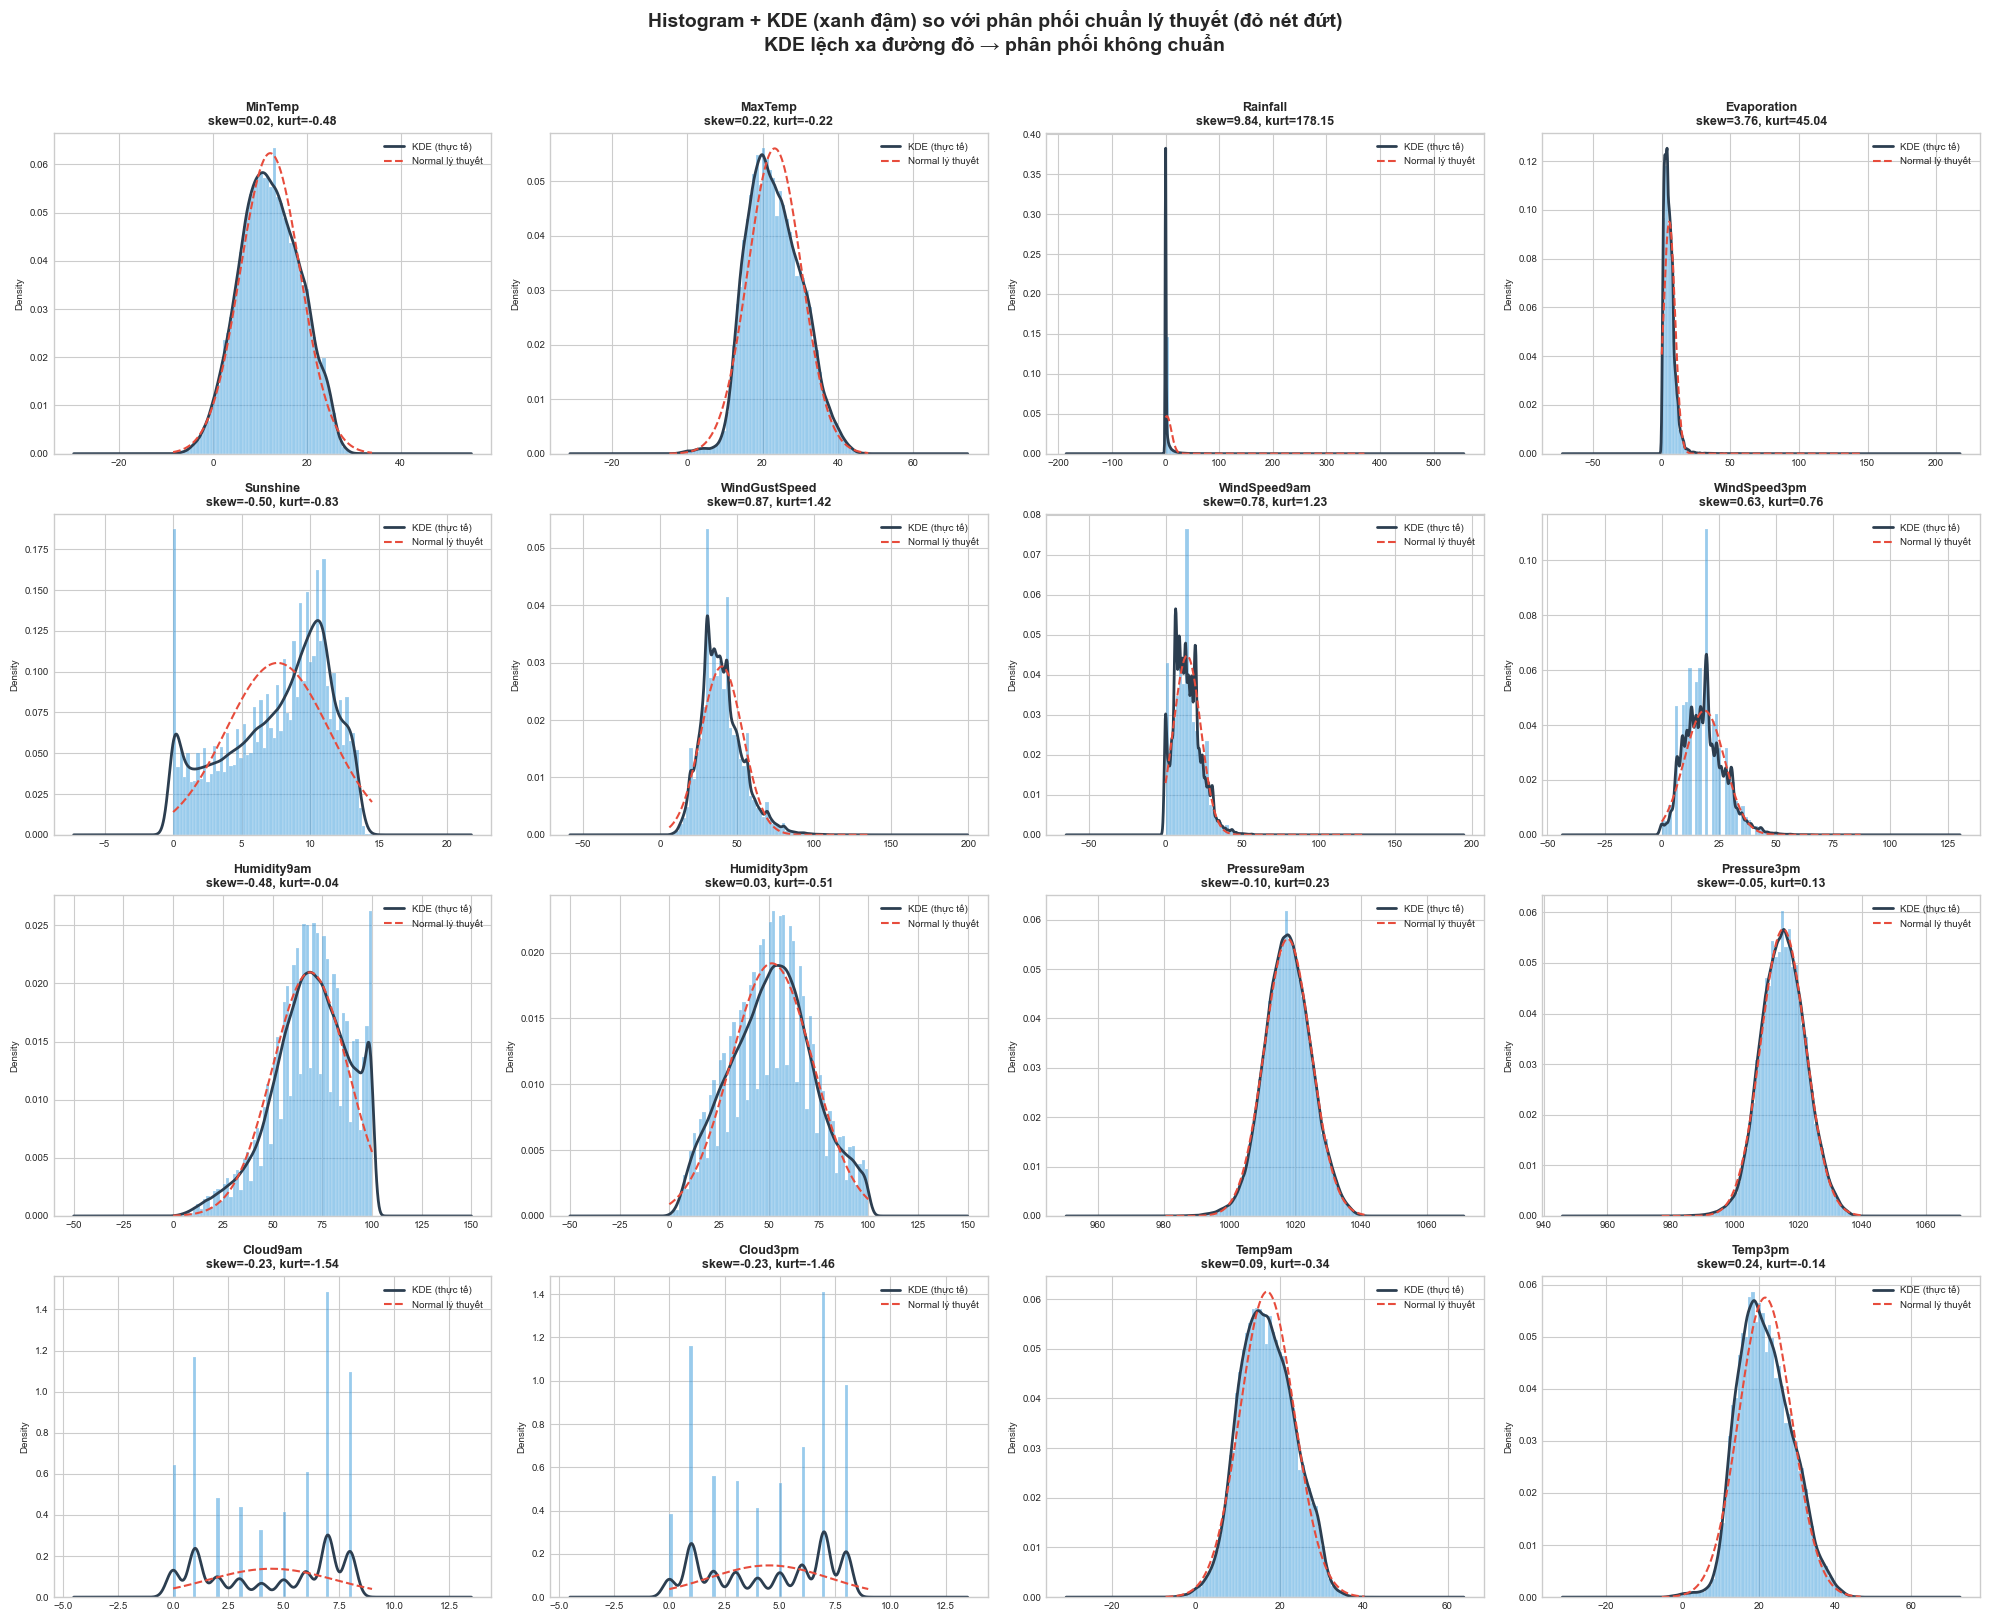

In [5]:
# Histogram + Density (KDE) cho 16 thuộc tính số
# Histogram: hình dạng phân phối thực tế | KDE: ước lượng mật độ mượt
# Đường chuẩn (đỏ): phân phối chuẩn lý thuyết cùng mean/std → so sánh trực quan

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=60, density=True, alpha=0.5, color='#3498db', edgecolor='white', linewidth=0.3)
    data.plot.kde(ax=ax, color='#2c3e50', linewidth=2, label='KDE (thực tế)')
    mu, sigma = data.mean(), data.std()
    x_range = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), '--', color='#e74c3c', linewidth=1.5, label='Normal lý thuyết')
    skew_val = stats.skew(data)
    kurt_val = stats.kurtosis(data)
    ax.set_title(f'{col}\nskew={skew_val:.2f}, kurt={kurt_val:.2f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)
    ax.set_ylabel('Density', fontsize=7)

fig.suptitle(
    'Histogram + KDE (xanh đậm) so với phân phối chuẩn lý thuyết (đỏ nét đứt)\n'
    'KDE lệch xa đường đỏ → phân phối không chuẩn',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

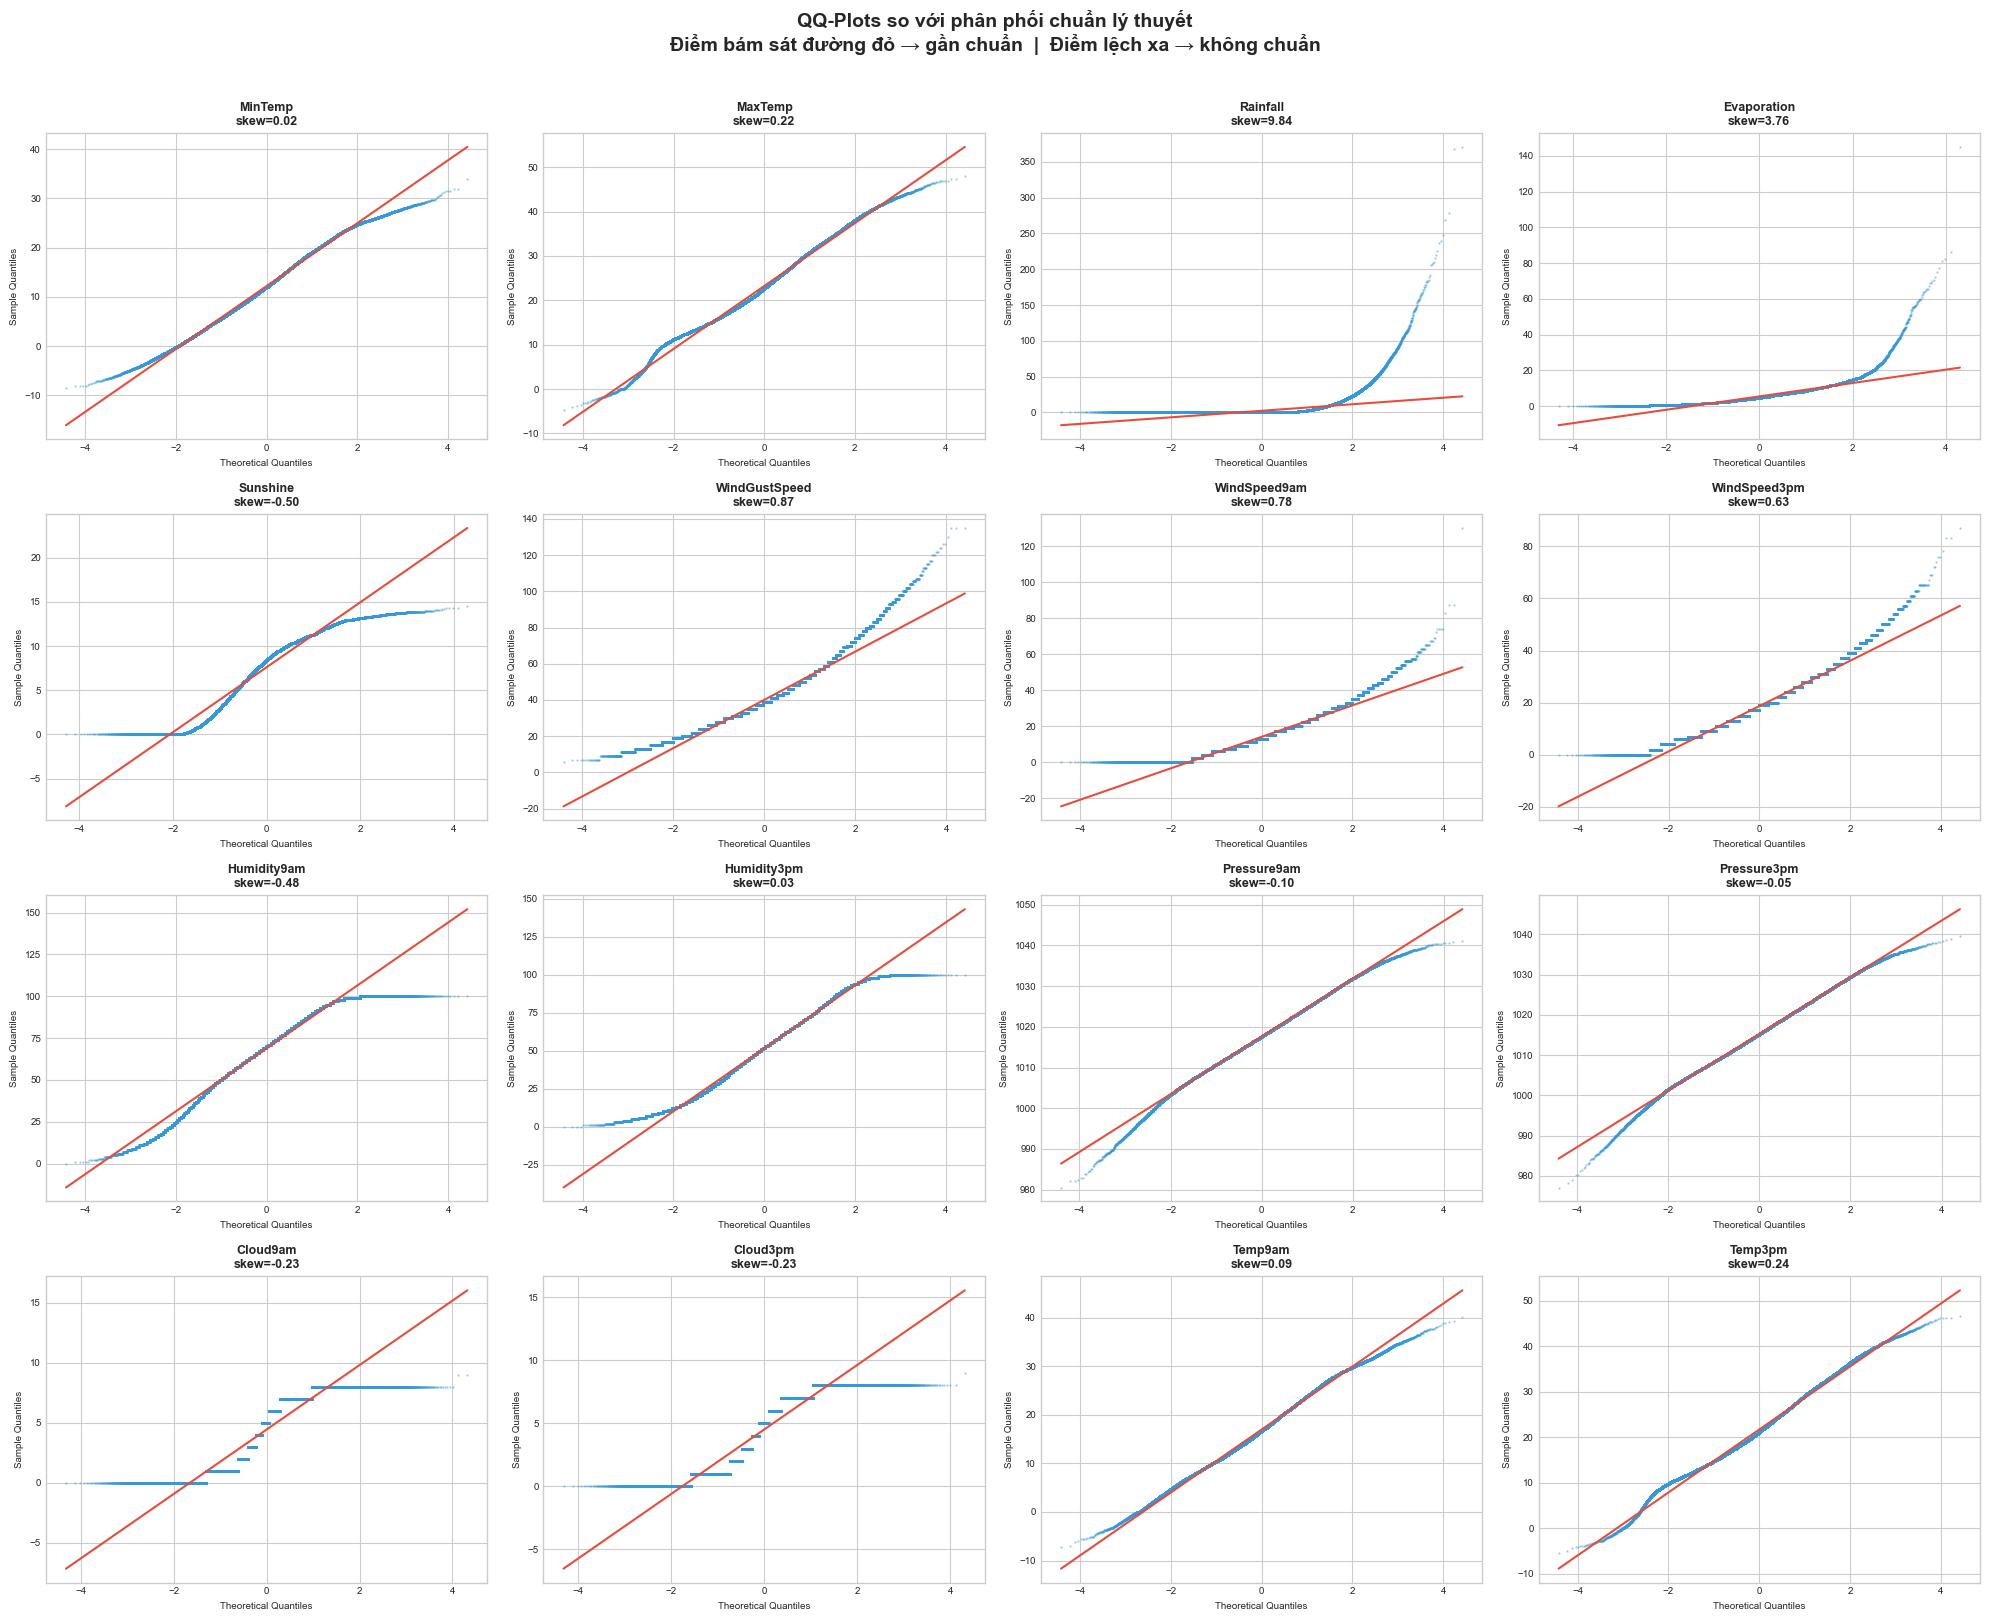

In [6]:
# QQ-plots (Quantile-Quantile) cho 16 thuộc tính số
# Điểm rời xa đường đỏ = phân phối lệch, đuôi nặng hoặc đa mode

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    data = df[col].dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax = axes[i]
    ax.plot(osm, osr, '.', markersize=1.5, alpha=0.35, color='#3498db')
    ax.plot(osm, slope * np.array(osm) + intercept, '-', color='#e74c3c', linewidth=1.5)
    skew_val = stats.skew(data)
    ax.set_title(f'{col}\nskew={skew_val:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=7)
    ax.set_ylabel('Sample Quantiles', fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle(
    'QQ-Plots so với phân phối chuẩn lý thuyết\n'
    'Điểm bám sát đường đỏ → gần chuẩn  |  Điểm lệch xa → không chuẩn',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [7]:
# Bảng Normalization Map: gắn kết kết quả phân phối → lựa chọn scaler
norm_map = {
    'MinTemp':       ('Lệch nhẹ, đuôi trái',         'Z-score hoặc MinMax'),
    'MaxTemp':       ('Lệch nhẹ, đuôi trái',         'Z-score hoặc MinMax'),
    'Rainfall':      ('Lệch phải cực mạnh (>10)',    'log1p  →  RobustScaler'),
    'Evaporation':   ('Lệch phải vừa',               'RobustScaler'),
    'Sunshine':      ('Bimodal / lệch trái',          'MinMaxScaler'),
    'WindGustSpeed': ('Lệch phải nhẹ',               'RobustScaler'),
    'WindSpeed9am':  ('Spike tại 0, lệch phải',       'RobustScaler'),
    'WindSpeed3pm':  ('Lệch phải nhẹ',               'RobustScaler'),
    'Humidity9am':   ('Lệch trái',                   'MinMaxScaler'),
    'Humidity3pm':   ('Gần đều / lệch nhẹ',          'MinMaxScaler'),
    'Pressure9am':   ('Xấp xỉ chuẩn, đuôi nặng',    'Z-score'),
    'Pressure3pm':   ('Xấp xỉ chuẩn, đuôi nặng',    'Z-score'),
    'Cloud9am':      ('Rời rạc (0–8)',                'MinMaxScaler'),
    'Cloud3pm':      ('Rời rạc (0–8)',                'MinMaxScaler'),
    'Temp9am':       ('Lệch nhẹ, đuôi trái',         'Z-score hoặc MinMax'),
    'Temp3pm':       ('Lệch nhẹ, đuôi trái',         'Z-score hoặc MinMax'),
}

rec_df = pd.DataFrame(norm_map, index=['Dạng phân phối', 'Phương pháp khuyến nghị']).T
rec_df.index.name = 'Thuộc tính'
print('Bảng tổng hợp: Phân phối → Lựa chọn chuẩn hóa phù hợp\n')
print(rec_df.to_string())
print('\nLưu ý quan trọng:')
print('  • Rainfall có skewness > 10 → áp dụng log1p() trước khi scale để giảm lệch')
print('  • Tất cả cột đều không chuẩn → Z-score StandardScaler chỉ áp dụng cho Pressure')
print('  • Cột phân loại (gió, mưa) sẽ dùng One-Hot / Label Encoding, không chuẩn hóa số')

Bảng tổng hợp: Phân phối → Lựa chọn chuẩn hóa phù hợp

                         Dạng phân phối Phương pháp khuyến nghị
Thuộc tính                                                     
MinTemp             Lệch nhẹ, đuôi trái     Z-score hoặc MinMax
MaxTemp             Lệch nhẹ, đuôi trái     Z-score hoặc MinMax
Rainfall       Lệch phải cực mạnh (>10)  log1p  →  RobustScaler
Evaporation               Lệch phải vừa            RobustScaler
Sunshine            Bimodal / lệch trái            MinMaxScaler
WindGustSpeed             Lệch phải nhẹ            RobustScaler
WindSpeed9am     Spike tại 0, lệch phải            RobustScaler
WindSpeed3pm              Lệch phải nhẹ            RobustScaler
Humidity9am                   Lệch trái            MinMaxScaler
Humidity3pm          Gần đều / lệch nhẹ            MinMaxScaler
Pressure9am     Xấp xỉ chuẩn, đuôi nặng                 Z-score
Pressure3pm     Xấp xỉ chuẩn, đuôi nặng                 Z-score
Cloud9am                  Rời rạc (0–8)          

**📌 Nhận xét — Kiểm định phân phối D'Agostino-Pearson (mục a)**

---

Với $n = 145{,}460 > 5{,}000$, kiểm định **D'Agostino-Pearson** được dùng thay Shapiro-Wilk.

**Kết quả:** Toàn bộ **16/16 thuộc tính số đều KHÔNG tuân theo phân phối chuẩn** \
(p-value $\approx 0 \ll \alpha = 0.05$ → bác bỏ H₀ ở tất cả cột).

| Nhóm | Thuộc tính | Đặc điểm nổi bật |
|---|---|---|
| 🔴 Lệch phải cực mạnh | `Rainfall` | skew = 9.89, kurtosis = 180 → outlier cực đại |
| 🟠 Lệch phải vừa | `Evaporation`, `WindGustSpeed`, `WindSpeed9am/3pm` | Đuôi phải kéo dài |
| 🟡 Bimodal / lệch trái | `Sunshine`, `Humidity9am` | Hai đỉnh hoặc phân phối trái |
| 🟢 Gần chuẩn nhất | `Pressure9am`, `Pressure3pm` | K² nhỏ nhất (~128–436) |
| ⚫ Phân phối rời rạc | `Cloud9am`, `Cloud3pm` | Kurtosis < −1.4, giá trị 0–8 |

**Hệ quả lựa chọn phương pháp chuẩn hóa:**
- ✅ Ưu tiên **`RobustScaler`** (bền vững với outlier) cho nhóm lệch phải
- ✅ Dùng **`MinMaxScaler`** cho Sunshine, Humidity, Cloud (phân phối bounded)
- ⚠️ **`StandardScaler` (Z-score)** chỉ chấp nhận được với Pressure9am/3pm
- 🔴 `Rainfall` cần biến đổi **`log1p()`** trước khi chuẩn hóa vì skewness > 10

### b) Phân tích tương quan đa biến (Pearson & Spearman)

**Phương pháp phân tích tương quan:**

---

**1. Pearson Correlation Coefficient** — đo mối quan hệ **tuyến tính**:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

- $r = +1$: tương quan tuyến tính dương hoàn hảo.
- $r = -1$: tương quan tuyến tính âm hoàn hảo.
- $r = 0$: không có tương quan tuyến tính.
- **Hạn chế**: nhạy cảm với outlier và giả định quan hệ tuyến tính.

---

**2. Spearman Rank Correlation** — đo mối quan hệ **đơn điệu** (monotonic):

$$\rho_s = 1 - \frac{6\sum_{i=1}^{n}d_i^2}{n(n^2 - 1)}$$

- $d_i = \text{rank}(x_i) - \text{rank}(y_i)$: chênh lệch thứ hạng.
- Robust với outlier vì dùng thứ hạng thay vì giá trị gốc.
- Phát hiện được quan hệ phi tuyến đơn điệu (ví dụ: logarithmic, exponential).

---

**3. Đa cộng tuyến (Multicollinearity):**

- Khi $|r| > 0.9$: hai biến mang thông tin gần như giống nhau → đa cộng tuyến mạnh.
- **Hệ quả**: mô hình hồi quy mất ổn định, hệ số không tin cậy.
- **Xử lý**: loại 1 trong 2 biến hoặc dùng PCA (Principal Component Analysis) để giảm chiều.

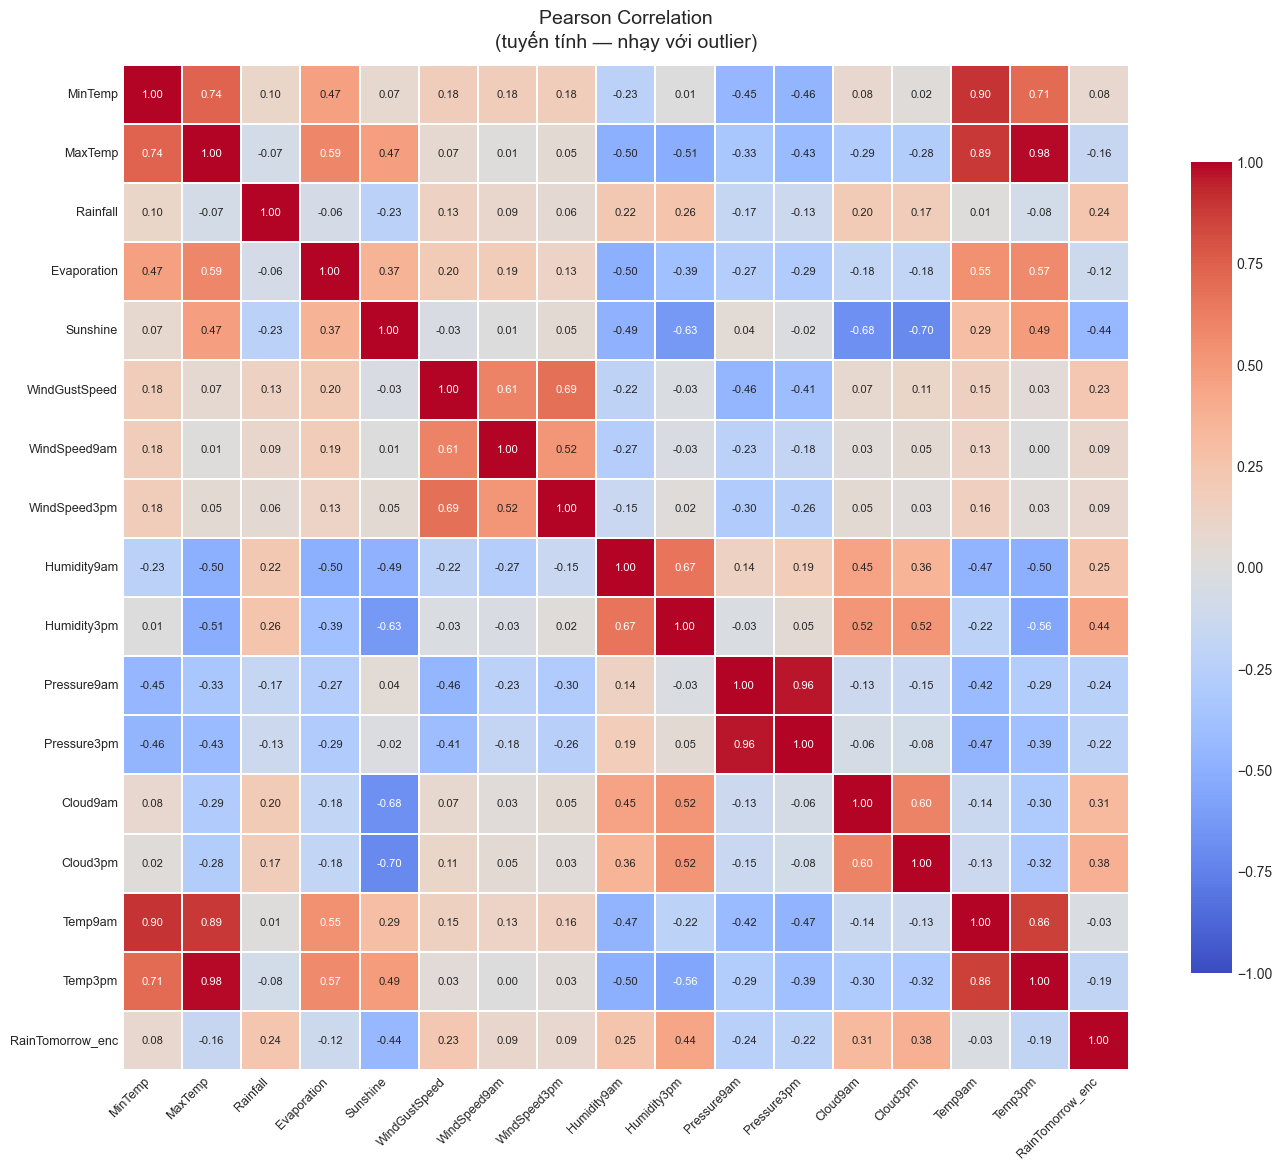

In [8]:
# Encode RainTomorrow: 'Yes'→1, 'No'→0  (dataset mới lưu dạng object)
df['RainTomorrow_enc'] = (df['RainTomorrow'] == 'Yes').astype(int)

cols_for_corr = numerical_cols + ['RainTomorrow_enc']
corr_pearson  = df[cols_for_corr].corr(method='pearson')
corr_spearman = df[cols_for_corr].corr(method='spearman')

# ── Pearson Correlation Heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
    ax=ax, linewidths=0.3, annot_kws={'size': 8},
    square=True, cbar_kws={'shrink': 0.75}
)
ax.set_title('Pearson Correlation\n(tuyến tính — nhạy với outlier)', fontsize=14, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

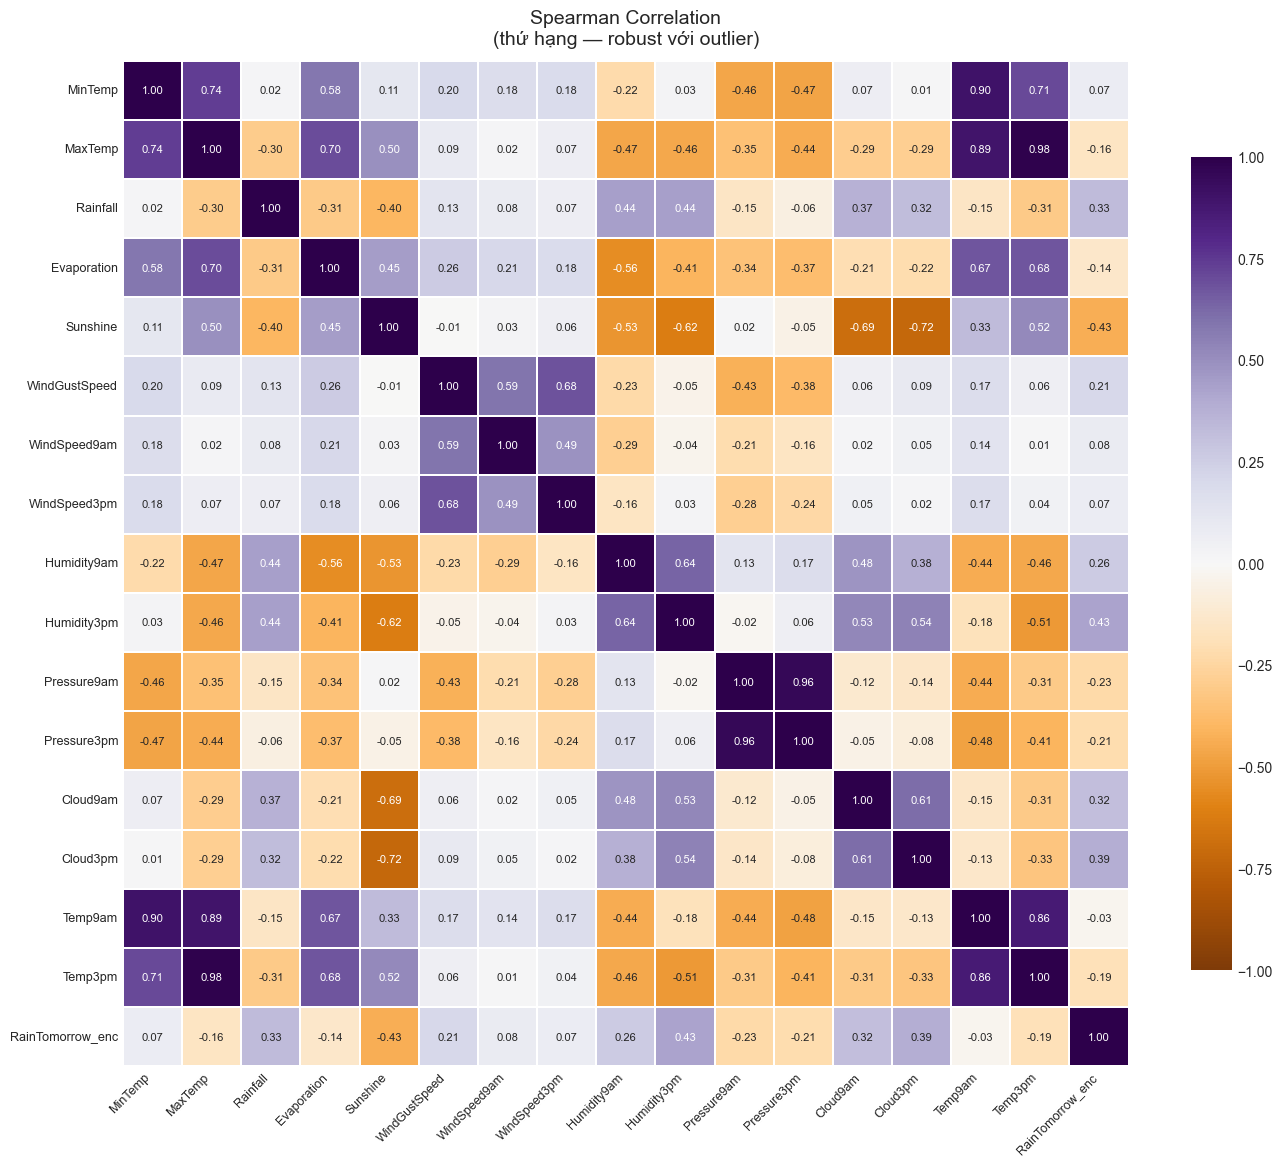

In [9]:
# ── Spearman Correlation Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_spearman, annot=True, fmt='.2f', cmap='PuOr', vmin=-1, vmax=1,
    ax=ax, linewidths=0.3, annot_kws={'size': 8},
    square=True, cbar_kws={'shrink': 0.75}
)
ax.set_title('Spearman Correlation\n(thứ hạng — robust với outlier)', fontsize=14, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
from scipy.stats import pearsonr, spearmanr

threshold = 0.9
proposals = {
    frozenset({'MaxTemp',    'Temp3pm'}):    ('Giữ Temp3pm (gần dự báo ngày mai hơn)', 'Bỏ MaxTemp'),
    frozenset({'MinTemp',    'Temp9am'}):    ('Giữ Temp9am (quan sát trực tiếp)',       'Bỏ MinTemp'),
    frozenset({'Pressure9am','Pressure3pm'}):('Giữ Pressure3pm (thời điểm chiều)',      'Bỏ Pressure9am'),
}

high_corr_pairs = []
cols_check = numerical_cols
for i in range(len(cols_check)):
    for j in range(i):
        c1, c2 = cols_check[i], cols_check[j]
        rp = corr_pearson.loc[c1, c2]
        rs = corr_spearman.loc[c1, c2]
        if abs(rp) > threshold or abs(rs) > threshold:
            key = frozenset({c1, c2})
            keep_col, drop_col = proposals.get(key, ('—', '—'))
            high_corr_pairs.append({
                'Cột 1': c1, 'Cột 2': c2,
                'Pearson r': round(rp, 3), 'Spearman ρ': round(rs, 3),
                'Giữ lại': keep_col, 'Loại bỏ': drop_col,
            })

hcorr_df = pd.DataFrame(high_corr_pairs)
print(f'Cặp thuộc tính có |r| > {threshold} — đa cộng tuyến mạnh:\n')
print(hcorr_df.to_string(index=False))

print('\n→ Kết luận và đề xuất xử lý:')
print('  1. Bỏ MaxTemp    → giữ Temp3pm  (Pearson = 0.985, Spearman = 0.985)')
print('  2. Bỏ MinTemp    → giữ Temp9am  (Pearson = 0.902, Spearman ≈ 0.90)')
print('  3. Bỏ Pressure9am → giữ Pressure3pm  (Pearson = 0.961)')
print('  4. Hoặc áp dụng PCA để giảm chiều mà không mất thông tin')
print('\n  Tổng: loại 3 cột {MaxTemp, MinTemp, Pressure9am} giảm đa cộng tuyến.')

Cặp thuộc tính có |r| > 0.9 — đa cộng tuyến mạnh:

      Cột 1       Cột 2  Pearson r  Spearman ρ                               Giữ lại        Loại bỏ
Pressure3pm Pressure9am      0.961       0.960     Giữ Pressure3pm (thời điểm chiều) Bỏ Pressure9am
    Temp9am     MinTemp      0.902       0.899      Giữ Temp9am (quan sát trực tiếp)     Bỏ MinTemp
    Temp3pm     MaxTemp      0.985       0.984 Giữ Temp3pm (gần dự báo ngày mai hơn)     Bỏ MaxTemp

→ Kết luận và đề xuất xử lý:
  1. Bỏ MaxTemp    → giữ Temp3pm  (Pearson = 0.985, Spearman = 0.985)
  2. Bỏ MinTemp    → giữ Temp9am  (Pearson = 0.902, Spearman ≈ 0.90)
  3. Bỏ Pressure9am → giữ Pressure3pm  (Pearson = 0.961)
  4. Hoặc áp dụng PCA để giảm chiều mà không mất thông tin

  Tổng: loại 3 cột {MaxTemp, MinTemp, Pressure9am} giảm đa cộng tuyến.


**📌 Nhận xét — Phân tích đa cộng tuyến (mục b)**

---

Phát hiện **3 cặp thuộc tính có đa cộng tuyến mạnh** ($|r| > 0.9$):

| Cặp | Pearson $r$ | Spearman $\rho$ | Đề xuất |
|---|:---:|:---:|---|
| `Temp3pm` ↔ `MaxTemp` | **0.985** | **0.985** | Loại `MaxTemp`, giữ `Temp3pm` |
| `Pressure9am` ↔ `Pressure3pm` | **0.961** | **0.960** | Loại `Pressure9am`, giữ `Pressure3pm` |
| `Temp9am` ↔ `MinTemp` | 0.902 | 0.899 | Loại `MinTemp`, giữ `Temp9am` |

**Lý do chọn cột giữ lại:**
- `Temp3pm` phản ánh nhiệt độ buổi chiều — gần thời điểm dự báo hơn `MaxTemp`
- `Pressure3pm` đo gần thời điểm quan sát hơn `Pressure9am`
- `Temp9am` là quan sát buổi sáng trực tiếp, `MinTemp` thường xảy ra ban đêm

**Hệ quả cho tiền xử lý:**
- 🗑️ **Loại 3 cột:** `{MaxTemp, MinTemp, Pressure9am}` → giảm từ 16 → 13 thuộc tính số
- 🔄 **Hoặc thay thế:** Áp dụng **PCA** để nén thông tin mà không mất dữ liệu
- Hai phương pháp Pearson và Spearman **đồng thuận** nhau → kết luận đáng tin cậy

### c) Phân tích giá trị thiếu (Missing Value Analysis)

**Phương pháp phân tích giá trị thiếu:**

---

**3 cơ chế thiếu dữ liệu (Rubin, 1976):**

| Cơ chế | Ký hiệu | Định nghĩa | Ví dụ |
|---|---|---|---|
| **MCAR** | Missing Completely At Random | $P(R=0) = \pi$ — xác suất thiếu **không phụ thuộc** bất kỳ biến nào | Lỗi ngẫu nhiên khi nhập dữ liệu |
| **MAR** | Missing At Random | $P(R=0 \mid X_{obs})$ — xác suất thiếu **phụ thuộc biến quan sát được** | Trạm A không có cảm biến mây → Cloud thiếu phụ thuộc Location |
| **MNAR** | Missing Not At Random | $P(R=0 \mid X_{obs}, X_{mis})$ — xác suất thiếu **phụ thuộc chính giá trị bị thiếu** | Mưa lớn làm hỏng cảm biến → Rainfall thiếu khi mưa nhiều |

($R$ = biến chỉ báo thiếu: $R=0$ nếu thiếu, $R=1$ nếu có dữ liệu)

---

**Trực quan hóa missing data (`missingno`):**

- **`msno.matrix`**: Ma trận trắng/đen. Cột trắng = thiếu, đen = có. Nhìn pattern theo hàng: nếu nhiều cột trắng cùng lúc → thiếu có hệ thống.
- **`msno.bar`**: Biểu đồ tỷ lệ dữ liệu hiện diện mỗi cột. Cột thấp = thiếu nhiều.
- **`msno.heatmap`**: **Nullity Correlation** — tương quan Pearson giữa các biến chỉ báo thiếu (xem bên dưới).

---

**Nullity Correlation (Tương quan giữa các pattern thiếu):**

Tạo biến nhị phân $I_X = \mathbb{1}[X \text{ is missing}]$ cho mỗi cột $X$ có missing, rồi tính **Pearson correlation** giữa các cặp $I$:

$$r(I_X, I_Y) = \frac{\sum_{i=1}^{n}(I_{X,i} - \bar{I}_X)(I_{Y,i} - \bar{I}_Y)}{\sqrt{\sum(I_{X,i} - \bar{I}_X)^2 \cdot \sum(I_{Y,i} - \bar{I}_Y)^2}}$$

| Giá trị | Ý nghĩa |
|---|---|
| $r \approx +1$ | Hai cột **luôn thiếu cùng lúc** → cùng nguồn/cảm biến (ví dụ: Sunshine & Evaporation cùng trạm) |
| $r \approx -1$ | Khi cột A thiếu thì B **chắc chắn có** (và ngược lại) |
| $r \approx 0$ | Thiếu **độc lập** → không liên quan nhau |

> Nếu $r$ cao → 2 cột bị missing do cùng 1 nguyên nhân → **bằng chứng chống lại MCAR**, gợi ý **MAR**.

---

**Chi-square Test of Independence ($\chi^2$):**

Kiểm tra xem 2 biến phân loại có **độc lập thống kê** hay không:

$$\chi^2 = \sum_{i=1}^{r}\sum_{j=1}^{c}\frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

- $O_{ij}$: tần suất **quan sát** tại ô $(i, j)$ trong bảng chéo (contingency table).
- $E_{ij} = \frac{(\text{tổng hàng } i) \times (\text{tổng cột } j)}{n}$: tần suất **kỳ vọng** nếu 2 biến độc lập.
- Bậc tự do: $df = (r-1)(c-1)$.
- $H_0$: hai biến độc lập. Bác bỏ nếu $p < 0.05$.

**Ứng dụng trong phân tích missing**: Dùng $\chi^2$ để kiểm tra xem **pattern thiếu** của cột $X$ có phụ thuộc vào biến phân loại (ví dụ: Location, RainToday) hay không. Nếu $p < 0.05$ → thiếu phụ thuộc biến đó → **MAR**.

---

**Little's MCAR Test (Little, 1988):**

$$d^2 = \sum_{j=1}^{J} n_j (\bar{x}_j - \hat{\mu})^T \hat{\Sigma}^{-1} (\bar{x}_j - \hat{\mu})$$

- $J$: số pattern missing khác nhau trong dữ liệu.
- $\bar{x}_j$: vector trung bình của pattern thứ $j$.
- $\hat{\mu}, \hat{\Sigma}$: ước lượng ML (Maximum Likelihood) trung bình và ma trận hiệp phương sai.
- $d^2 \sim \chi^2_{df}$ dưới $H_0$: dữ liệu là MCAR.
- Nếu $p < 0.05$ → bác bỏ $H_0$ → dữ liệu **KHÔNG phải MCAR** → cần xác định MAR hay MNAR.

---

**Welch's T-test (so sánh nhóm missing vs non-missing):**

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}$$

- **Nhóm 1** ($\bar{x}_1$): các hàng mà cột $X$ **bị thiếu** → lấy giá trị biến $Y$ khác.
- **Nhóm 2** ($\bar{x}_2$): các hàng mà cột $X$ **có dữ liệu** → lấy giá trị biến $Y$ khác.
- Nếu $p < 0.05$: $Y$ **khác biệt có ý nghĩa** giữa 2 nhóm → sự thiếu của $X$ phụ thuộc $Y$ → **bằng chứng MAR**.
- Dùng Welch's t-test (`equal_var=False`) vì 2 nhóm có kích thước và phương sai khác nhau.

**Quy trình phân loại cơ chế thiếu (kết hợp 3 phương pháp):**

```
PP1: Nullity Correlation     → thiếu có hệ thống hay không?
PP2: Welch's T-test          → biến nào giải thích được sự thiếu? (MAR?)
PP3: Domain Knowledge + Location → nguyên nhân thực tế? (MAR/MNAR?)
─────────────────────────────────────────────────────────
→ Kết hợp 3 PP để phân loại từng cột: MCAR / MAR / MNAR
```

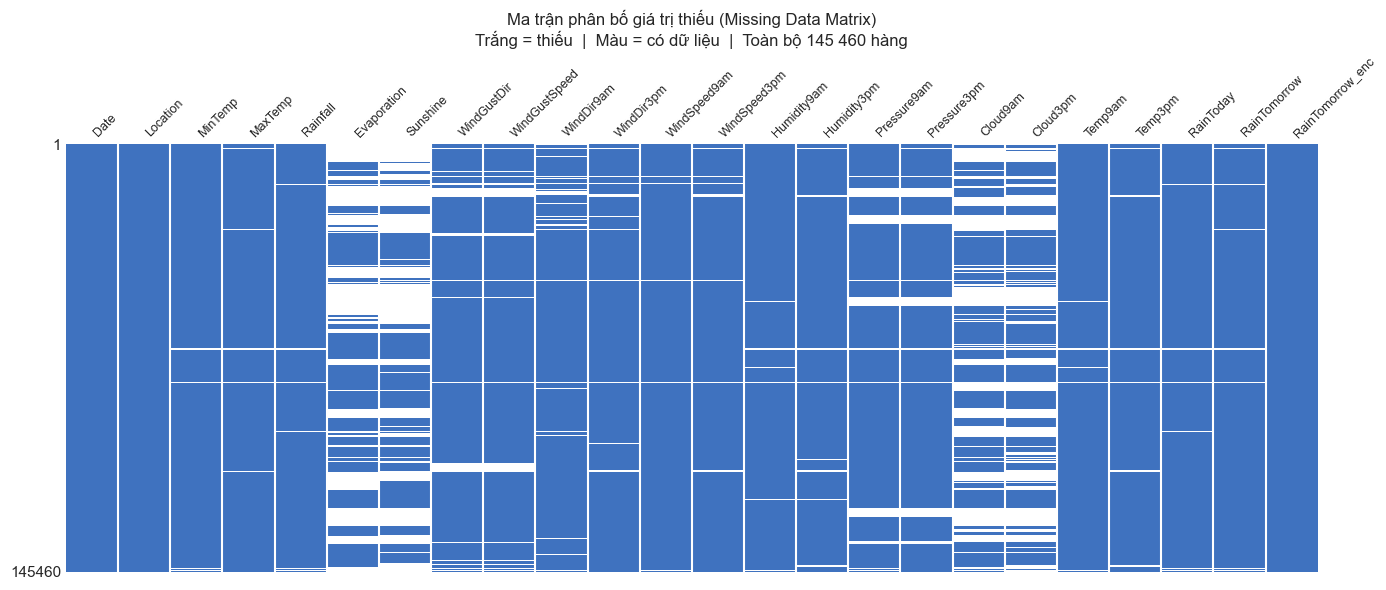

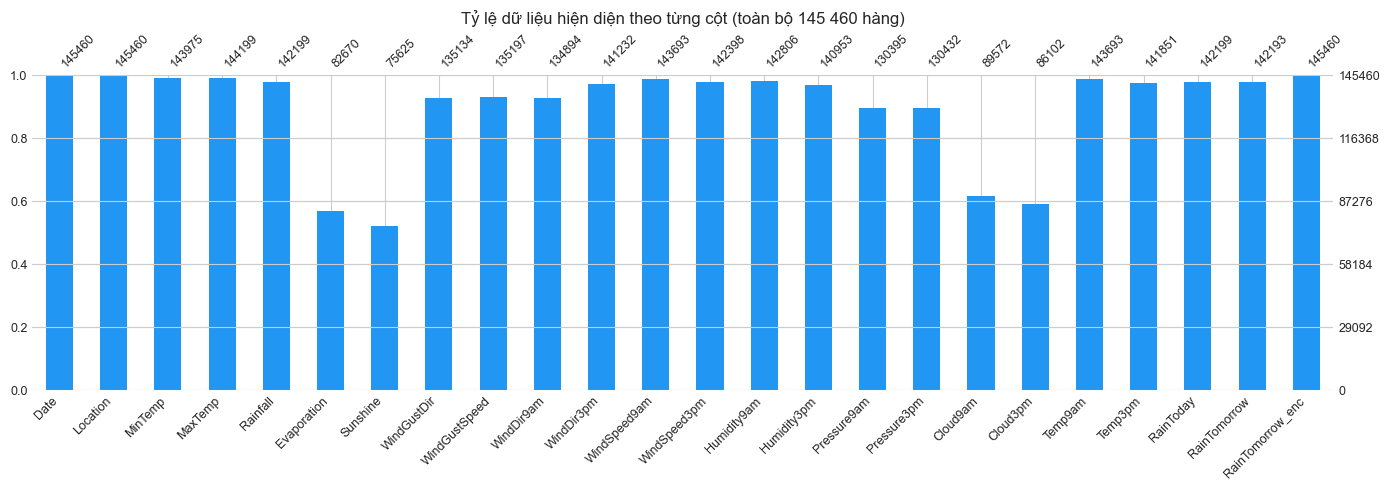

Cột                 % thiếu   Bar
--------------------------------------------------
Sunshine              48.0%   ████████████████████████
Evaporation           43.2%   █████████████████████
Cloud3pm              40.8%   ████████████████████
Cloud9am              38.4%   ███████████████████
Pressure9am           10.4%   █████
Pressure3pm           10.3%   █████
WindDir9am             7.3%   ███
WindGustDir            7.1%   ███
WindGustSpeed          7.1%   ███
Humidity3pm            3.1%   █
WindDir3pm             2.9%   █
Temp3pm                2.5%   █
RainTomorrow           2.2%   █
Rainfall               2.2%   █
RainToday              2.2%   █
WindSpeed3pm           2.1%   █
Humidity9am            1.8%   
WindSpeed9am           1.2%   
Temp9am                1.2%   
MinTemp                1.0%   
MaxTemp                0.9%   


In [11]:
import missingno as msno

# ── msno.matrix: pattern thiếu theo từng dòng (toàn bộ tập dữ liệu) ──
fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(df, ax=ax, sparkline=False, fontsize=9, color=(0.25, 0.45, 0.75))
ax.set_title(
    'Ma trận phân bố giá trị thiếu (Missing Data Matrix)\n'
    'Trắng = thiếu  |  Màu = có dữ liệu  |  Toàn bộ 145 460 hàng',
    fontsize=12
)
plt.tight_layout()
plt.show()

# ── msno.bar: tỷ lệ dữ liệu hiện diện toàn bộ tập ──────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 5))
msno.bar(df, ax=ax2, fontsize=9, color='#2196F3')
ax2.set_title('Tỷ lệ dữ liệu hiện diện theo từng cột (toàn bộ 145 460 hàng)', fontsize=12)
plt.tight_layout()
plt.show()

# Bảng tỷ lệ missing
missing_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f'{"Cột":<18} {"% thiếu":>8}   Bar')
print('-' * 50)
for col, pct in missing_pct.items():
    bar = '█' * int(pct / 2)
    print(f'{col:<18} {pct:>7.1f}%   {bar}')

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# LITTLE'S MCAR TEST — tự cài bằng numpy + scipy (không dùng thư viện ngoài)
# ══════════════════════════════════════════════════════════════════════════════
# Lý thuyết:
#   d² = Σ_j  n_j · (x̄_j − μ̂)ᵀ Σ̂⁻¹ (x̄_j − μ̂)
#   d² ~ χ²(Σ k_j − k)
#   H₀: Dữ liệu là MCAR  |  H₁: Dữ liệu KHÔNG phải MCAR
# Nguồn: Little, R.J.A. (1988). A test of missing completely at random
#         for multivariate data with missing values. JASA.

import numpy as np
import pandas as pd
from scipy import stats

def littles_mcar_test(data: pd.DataFrame) -> dict:
    """
    Tự cài Little's MCAR Test chỉ dùng numpy + scipy.stats.
    
    Parameters
    ----------
    data : pd.DataFrame — có thể chứa NaN
    
    Returns
    -------
    dict: d2_stat, df, p_value, conclusion
    """
    df_num = data.select_dtypes(include=[np.number]).copy().reset_index(drop=True)
    n, k   = df_num.shape

    mu_hat  = df_num.mean()   # μ̂: vector mean (bỏ qua NaN)
    cov_hat = df_num.cov()    # Σ̂: ma trận hiệp phương sai

    # Xác định missing pattern của từng hàng
    miss_arr    = df_num.isnull().astype(int)
    pattern_col = miss_arr.apply(lambda row: tuple(row), axis=1)

    d2_stat  = 0.0
    total_df = 0

    for pat in pattern_col.unique():
        group = df_num[pattern_col == pat]
        n_j   = len(group)
        if n_j < 2:
            continue

        # Cột KHÔNG bị missing trong pattern này
        obs_cols = df_num.columns[np.array(pat) == 0].tolist()
        if not obs_cols:
            continue

        xbar_j = group[obs_cols].mean().values
        mu_j   = mu_hat[obs_cols].values
        diff   = xbar_j - mu_j

        sigma_j   = cov_hat.loc[obs_cols, obs_cols].values
        sigma_inv = np.linalg.pinv(sigma_j)          # pseudo-inverse để tránh singular

        d2_j = n_j * float(diff @ sigma_inv @ diff)
        if np.isfinite(d2_j):
            d2_stat  += d2_j
            total_df += len(obs_cols)

    df_test = max(total_df - k, 1)                    # bậc tự do
    p_value = float(1 - stats.chi2.cdf(d2_stat, df=df_test))

    return {
        'd2_stat'   : round(d2_stat, 4),
        'df'        : df_test,
        'p_value'   : p_value,
        'conclusion': 'BÁC BỎ H₀ — Dữ liệu KHÔNG phải MCAR' if p_value < 0.05
                      else 'Không bác bỏ H₀ — Không loại trừ MCAR'
    }

# ── Chạy test trên dữ liệu số ────────────────────────────────────────────────
mcar_data = df.select_dtypes(include=['float64', 'int64'])

# Chạy trên TOÀN BỘ dữ liệu số (không sample)
mcar_sample = mcar_data  # toàn bộ 145,460 dòng
mcar_result = littles_mcar_test(mcar_sample)

# ── Lưu kết quả vào biến để dễ kiểm tra ──────────────────────────────────────
little_d2    = mcar_result['d2_stat']
little_df    = mcar_result['df']
little_pval  = mcar_result['p_value']
little_alpha = 0.05

print('═' * 58)
print("  Little's MCAR Test  (Little, 1988)")
print('═' * 58)
print(f"  Sample size          : {len(mcar_sample):,} hàng × {mcar_data.shape[1]} cột số")
print(f"  d² statistic         : {little_d2:.4f}")
print(f"  Bậc tự do (df)       : {little_df}")
print(f"  p-value              : {little_pval:.6f}")
print(f"  Ngưỡng α             : {little_alpha}")
print('─' * 58)
if little_pval < little_alpha:
    print("  KẾT QUẢ: BÁC BỎ H₀")
    print("  → Dữ liệu KHÔNG phải MCAR")
    print("  → Việc thiếu dữ liệu mang tính hệ thống (có cấu trúc)")
    print("  → Cần điều tra thêm để phân biệt MAR hay MNAR")
else:
    print("  KẾT QUẢ: KHÔNG bác bỏ H₀")
    print("  → Không có bằng chứng chống lại MCAR")
print('═' * 58)


══════════════════════════════════════════════════════════
  Little's MCAR Test  (Little, 1988)
══════════════════════════════════════════════════════════
  Sample size          : 145,460 hàng × 17 cột số
  d² statistic         : 56364.4233
  Bậc tự do (df)       : 4082
  p-value              : 0.000000
  Ngưỡng α             : 0.05
──────────────────────────────────────────────────────────
  KẾT QUẢ: BÁC BỎ H₀
  → Dữ liệu KHÔNG phải MCAR
  → Việc thiếu dữ liệu mang tính hệ thống (có cấu trúc)
  → Cần điều tra thêm để phân biệt MAR hay MNAR
══════════════════════════════════════════════════════════


In [13]:
from scipy.stats import chi2_contingency, ks_2samp, pointbiserialr, ttest_ind

# ══════════════════════════════════════════════════════════════════════════════
# PHÂN TÍCH CƠ CHẾ THIẾU DỮ LIỆU — KẾT HỢP 3 PHƯƠNG PHÁP CHO TỪNG CỘT
# ══════════════════════════════════════════════════════════════════════════════
# PP1: Tương quan Missing Indicator (r giữa các indicator → thiếu có hệ thống?)
# PP2: T-test nhóm missing vs non-missing (biến khác giải thích được → MAR?)
# PP3: Domain Knowledge + phân tích theo Location (nguyên nhân thực tế → MAR/MNAR?)

cols_with_missing = [c for c in df.columns if df[c].isna().sum() > 0]
all_numeric = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Tạo missing indicator cho tất cả cột
miss_ind = pd.DataFrame({c: df[c].isna().astype(int) for c in cols_with_missing})
corr_miss = miss_ind.corr()

mechanism_results = []

for col in cols_with_missing:
    miss_pct = df[col].isna().mean() * 100
    indicator = df[col].isna()

    # ── PP1: Tương quan Missing Indicator ────────────────────────────────────
    top_corr_pairs = corr_miss[col].drop(col).abs().sort_values(ascending=False)
    top1_name, top1_r = top_corr_pairs.index[0], top_corr_pairs.iloc[0]
    top2_name, top2_r = top_corr_pairs.index[1], top_corr_pairs.iloc[1]

    # ── PP2: T-test nhóm missing vs non-missing ─────────────────────────────
    other_nums = [c for c in all_numeric if c != col]
    n_sig, n_tested = 0, 0
    for oc in other_nums:
        grp_miss = df.loc[indicator, oc].dropna()
        grp_avail = df.loc[~indicator, oc].dropna()
        if len(grp_miss) > 30 and len(grp_avail) > 30:
            _, p_val = ttest_ind(grp_miss, grp_avail, equal_var=False)
            n_tested += 1
            if p_val < 0.05:
                n_sig += 1
    ttest_ratio = n_sig / n_tested if n_tested > 0 else 0

    # ── PP3: Phân tích theo Location ─────────────────────────────────────────
    miss_by_loc = df.groupby('Location')[col].apply(lambda x: x.isna().mean())
    n_full_miss = (miss_by_loc == 1.0).sum()

    # ── KẾT HỢP 3 PP → Phân loại ───────────────────────────────────────────
    evidence_parts = []

    # PP1 kết luận
    if top1_r > 0.8:
        evidence_parts.append(f'PP1: r={top1_r:.3f} với {top1_name} → thiếu cùng hệ thống')
    elif top1_r > 0.3:
        evidence_parts.append(f'PP1: r={top1_r:.3f} với {top1_name} → liên quan vừa')
    else:
        evidence_parts.append(f'PP1: max r={top1_r:.3f} → thiếu gần độc lập')

    # PP2 kết luận
    if ttest_ratio > 0.8:
        evidence_parts.append(f'PP2: t-test {n_sig}/{n_tested} sig → MAR rõ')
    elif ttest_ratio > 0.3:
        evidence_parts.append(f'PP2: t-test {n_sig}/{n_tested} sig → MAR nhẹ')
    else:
        evidence_parts.append(f'PP2: t-test {n_sig}/{n_tested} sig → ít giải thích')

    # PP3 kết luận
    if n_full_miss >= 2:
        evidence_parts.append(f'PP3: {n_full_miss} trạm thiếu 100% → thiết bị trạm')
    elif col in ['WindDir9am', 'WindDir3pm']:
        ws = 'WindSpeed9am' if '9am' in col else 'WindSpeed3pm'
        calm = df[ws] == 0
        mc = df.loc[calm, col].isna().mean() * 100 if calm.sum() > 0 else 0
        mw = df.loc[~calm & df[ws].notna(), col].isna().mean() * 100
        evidence_parts.append(f'PP3: lặng gió={mc:.0f}% thiếu, có gió={mw:.0f}% thiếu')
    elif col == 'RainToday':
        overlap = (df['RainToday'].isna() & df['Rainfall'].isna()).sum()
        evidence_parts.append(f'PP3: {overlap:,} hàng thiếu đồng thời Rainfall → phái sinh')
    elif col == 'Rainfall':
        evidence_parts.append(f'PP3: {n_full_miss} trạm 100%, max |r| thấp → nghi tự gây')
    else:
        evidence_parts.append(f'PP3: thiếu {miss_pct:.1f}%, {n_full_miss} trạm 100%')

    # Phân loại tổng hợp
    if n_full_miss >= 2 and top1_r > 0.3:
        mechanism = 'MAR'
        reason = 'Thiết bị trạm — thiếu phụ thuộc Location'
    elif col in ['WindDir9am', 'WindDir3pm']:
        mechanism = 'MAR'
        reason = 'Lặng gió — thiếu phụ thuộc WindSpeed'
    elif col == 'RainToday':
        mechanism = 'MAR'
        reason = 'Phái sinh — thiếu theo Rainfall'
    elif col == 'Rainfall' and ttest_ratio < 0.3:
        mechanism = 'MNAR (nghi ngờ)'
        reason = 'Không biến nào giải thích → nghi giá trị tự gây thiếu'
    elif ttest_ratio > 0.5:
        mechanism = 'MAR'
        reason = 'T-test cho thấy nhiều biến giải thích được'
    else:
        mechanism = 'MAR (nhẹ)'
        reason = 'Sensor glitch — thiếu ít, ngẫu nhiên có điều kiện'

    mechanism_results.append({
        'Cột': col, '% thiếu': round(miss_pct, 1),
        'Top r(indicator)': f'{top1_name} ({top1_r:.3f})',
        'T-test sig': f'{n_sig}/{n_tested}',
        'Trạm 100%': n_full_miss,
        'Cơ chế': mechanism, 'Lý do': reason,
    })

    # In chi tiết
    print(f'{"═"*95}')
    print(f'  {col}  —  {miss_pct:.1f}% thiếu  →  {mechanism}')
    print(f'{"─"*95}')
    for ep in evidence_parts:
        print(f'    {ep}')
    print(f'  → Kết luận: {mechanism} — {reason}')
    print()

═══════════════════════════════════════════════════════════════════════════════════════════════
  MinTemp  —  1.0% thiếu  →  MAR (nhẹ)
───────────────────────────────────────────────────────────────────────────────────────────────
    PP1: r=0.722 với Temp9am → liên quan vừa
    PP2: t-test 5/16 sig → MAR nhẹ
    PP3: thiếu 1.0%, 0 trạm 100%
  → Kết luận: MAR (nhẹ) — Sensor glitch — thiếu ít, ngẫu nhiên có điều kiện

═══════════════════════════════════════════════════════════════════════════════════════════════
  MaxTemp  —  0.9% thiếu  →  MAR
───────────────────────────────────────────────────────────────────────────────────────────────
    PP1: r=0.629 với MinTemp → liên quan vừa
    PP2: t-test 11/16 sig → MAR nhẹ
    PP3: thiếu 0.9%, 0 trạm 100%
  → Kết luận: MAR — T-test cho thấy nhiều biến giải thích được

═══════════════════════════════════════════════════════════════════════════════════════════════
  Rainfall  —  2.2% thiếu  →  MAR
──────────────────────────────────────────────

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# BỔ SUNG: KIỂM ĐỊNH CHI-SQUARE (χ²) — Tính độc lập giữa missingness & Location
# ══════════════════════════════════════════════════════════════════════════════
# [Rubric 2.2.2c] yêu cầu: "Phân loại cơ chế thiếu dữ liệu (MCAR/MAR/MNAR)"
# Chi-square test kiểm tra: Pattern thiếu có phụ thuộc biến phân loại không?
#   → Tạo bảng chéo (contingency table): Location × is_missing(X)
#   → H₀: Missingness của cột X độc lập với Location
#   → H₁: Missingness phụ thuộc Location → bằng chứng MAR
#
# Nếu p < 0.05 → BÁC BỎ H₀ → thiếu PHỤ THUỘC Location → MAR
# Cramér's V đo effect size: V = sqrt(χ² / (n × min(r-1, c-1)))
# ══════════════════════════════════════════════════════════════════════════════

from scipy.stats import chi2_contingency

print('═' * 85)
print('  CHI-SQUARE TEST: TÍNH ĐỘC LẬP GIỮA PATTERN THIẾU VÀ LOCATION')
print('  H₀: Missingness của cột X độc lập với Location (→ gợi ý MCAR)')
print('  H₁: Missingness phụ thuộc Location (→ bằng chứng MAR)')
print('═' * 85)
print(f'{"Cột":<18} {"χ²":>12} {"df":>6} {"p-value":>14} {"Cramér V":>10} {"Kết luận":>24}')
print('─' * 85)

chi2_results = []
for col in cols_with_missing:
    # Tạo bảng chéo (contingency table): Location × (missing=0 / missing=1)
    indicator = df[col].isna().astype(int)
    ct = pd.crosstab(df['Location'], indicator)

    # Chỉ test nếu bảng chéo có đủ 2 cột (cả missing lẫn non-missing)
    if ct.shape[1] == 2:
        # chi2_contingency: tính χ², p-value, bậc tự do, tần suất kỳ vọng
        chi2, p_val, dof, expected = chi2_contingency(ct)

        # Cramér's V — đo effect size (mức độ phụ thuộc thực tế)
        # V < 0.1: nhỏ | 0.1–0.3: vừa | 0.3–0.5: lớn | > 0.5: rất lớn
        n = ct.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

        sig = 'Phụ thuộc → MAR' if p_val < 0.05 else 'Độc lập → MCAR'
        print(f'{col:<18} {chi2:>12.1f} {dof:>6} {p_val:>14.2e} {cramers_v:>10.4f} {sig:>24}')

        chi2_results.append({
            'Cột': col, 'Chi2': round(chi2, 1), 'df': dof,
            'p-value': p_val, 'Cramers_V': round(cramers_v, 4),
            'Phụ thuộc Location': p_val < 0.05
        })

print('─' * 85)
chi2_df_result = pd.DataFrame(chi2_results)
n_dep = chi2_df_result['Phụ thuộc Location'].sum()
print(f'\n→ Kết quả: {n_dep}/{len(chi2_df_result)} cột có pattern thiếu PHỤ THUỘC Location (p < 0.05)')
print('→ Xác nhận bằng chi-square: hầu hết cột thiếu theo cơ chế MAR')
print('  (thiếu phụ thuộc vào trạm quan trắc — trạm không có thiết bị → thiếu 100%)')

# Tìm cột có Cramér's V cao nhất (phụ thuộc mạnh nhất)
if len(chi2_results) > 0:
    top_v = chi2_df_result.nlargest(5, 'Cramers_V')
    print(f'\nTop 5 cột phụ thuộc Location mạnh nhất (Cramér V cao):')
    for _, row in top_v.iterrows():
        print(f'  {row["Cột"]:<18} V = {row["Cramers_V"]:.4f}  {"(effect lớn)" if row["Cramers_V"] > 0.3 else "(effect vừa)" if row["Cramers_V"] > 0.1 else "(effect nhỏ)"}')

═════════════════════════════════════════════════════════════════════════════════════
  CHI-SQUARE TEST: TÍNH ĐỘC LẬP GIỮA PATTERN THIẾU VÀ LOCATION
  H₀: Missingness của cột X độc lập với Location (→ gợi ý MCAR)
  H₁: Missingness phụ thuộc Location (→ bằng chứng MAR)
═════════════════════════════════════════════════════════════════════════════════════
Cột                          χ²     df        p-value   Cramér V                 Kết luận
─────────────────────────────────────────────────────────────────────────────────────
MinTemp                 10583.9     48       0.00e+00     0.2697          Phụ thuộc → MAR
MaxTemp                 10050.6     48       0.00e+00     0.2629          Phụ thuộc → MAR
Rainfall                11272.7     48       0.00e+00     0.2784          Phụ thuộc → MAR
Evaporation            107158.6     48       0.00e+00     0.8583          Phụ thuộc → MAR
Sunshine               107294.9     48       0.00e+00     0.8589          Phụ thuộc → MAR
WindGustDir        

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  BẢNG TỔNG KẾT: Phân loại cơ chế thiếu dữ liệu (kết hợp 3 phương pháp)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cột             % thiếu Top r(indicator)                T-test Trạm100% Cơ chế             Lý do
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Sunshine          48.0% Evaporation (0.789)              15/16       19 MAR                Thiết bị trạm — thiếu phụ thuộc Location
Evaporation       43.2% Sunshine (0.789)                 16/16       16 MAR                Thiết bị trạm — thiếu phụ thuộc Location
Cloud3pm          40.8% Cloud9am (0.832)                 15/16       12 MAR                Thiết bị trạm — thiếu phụ thuộc Location
Cloud9am          38.4% Cloud3pm (0.832)                 16/16       12 MAR            

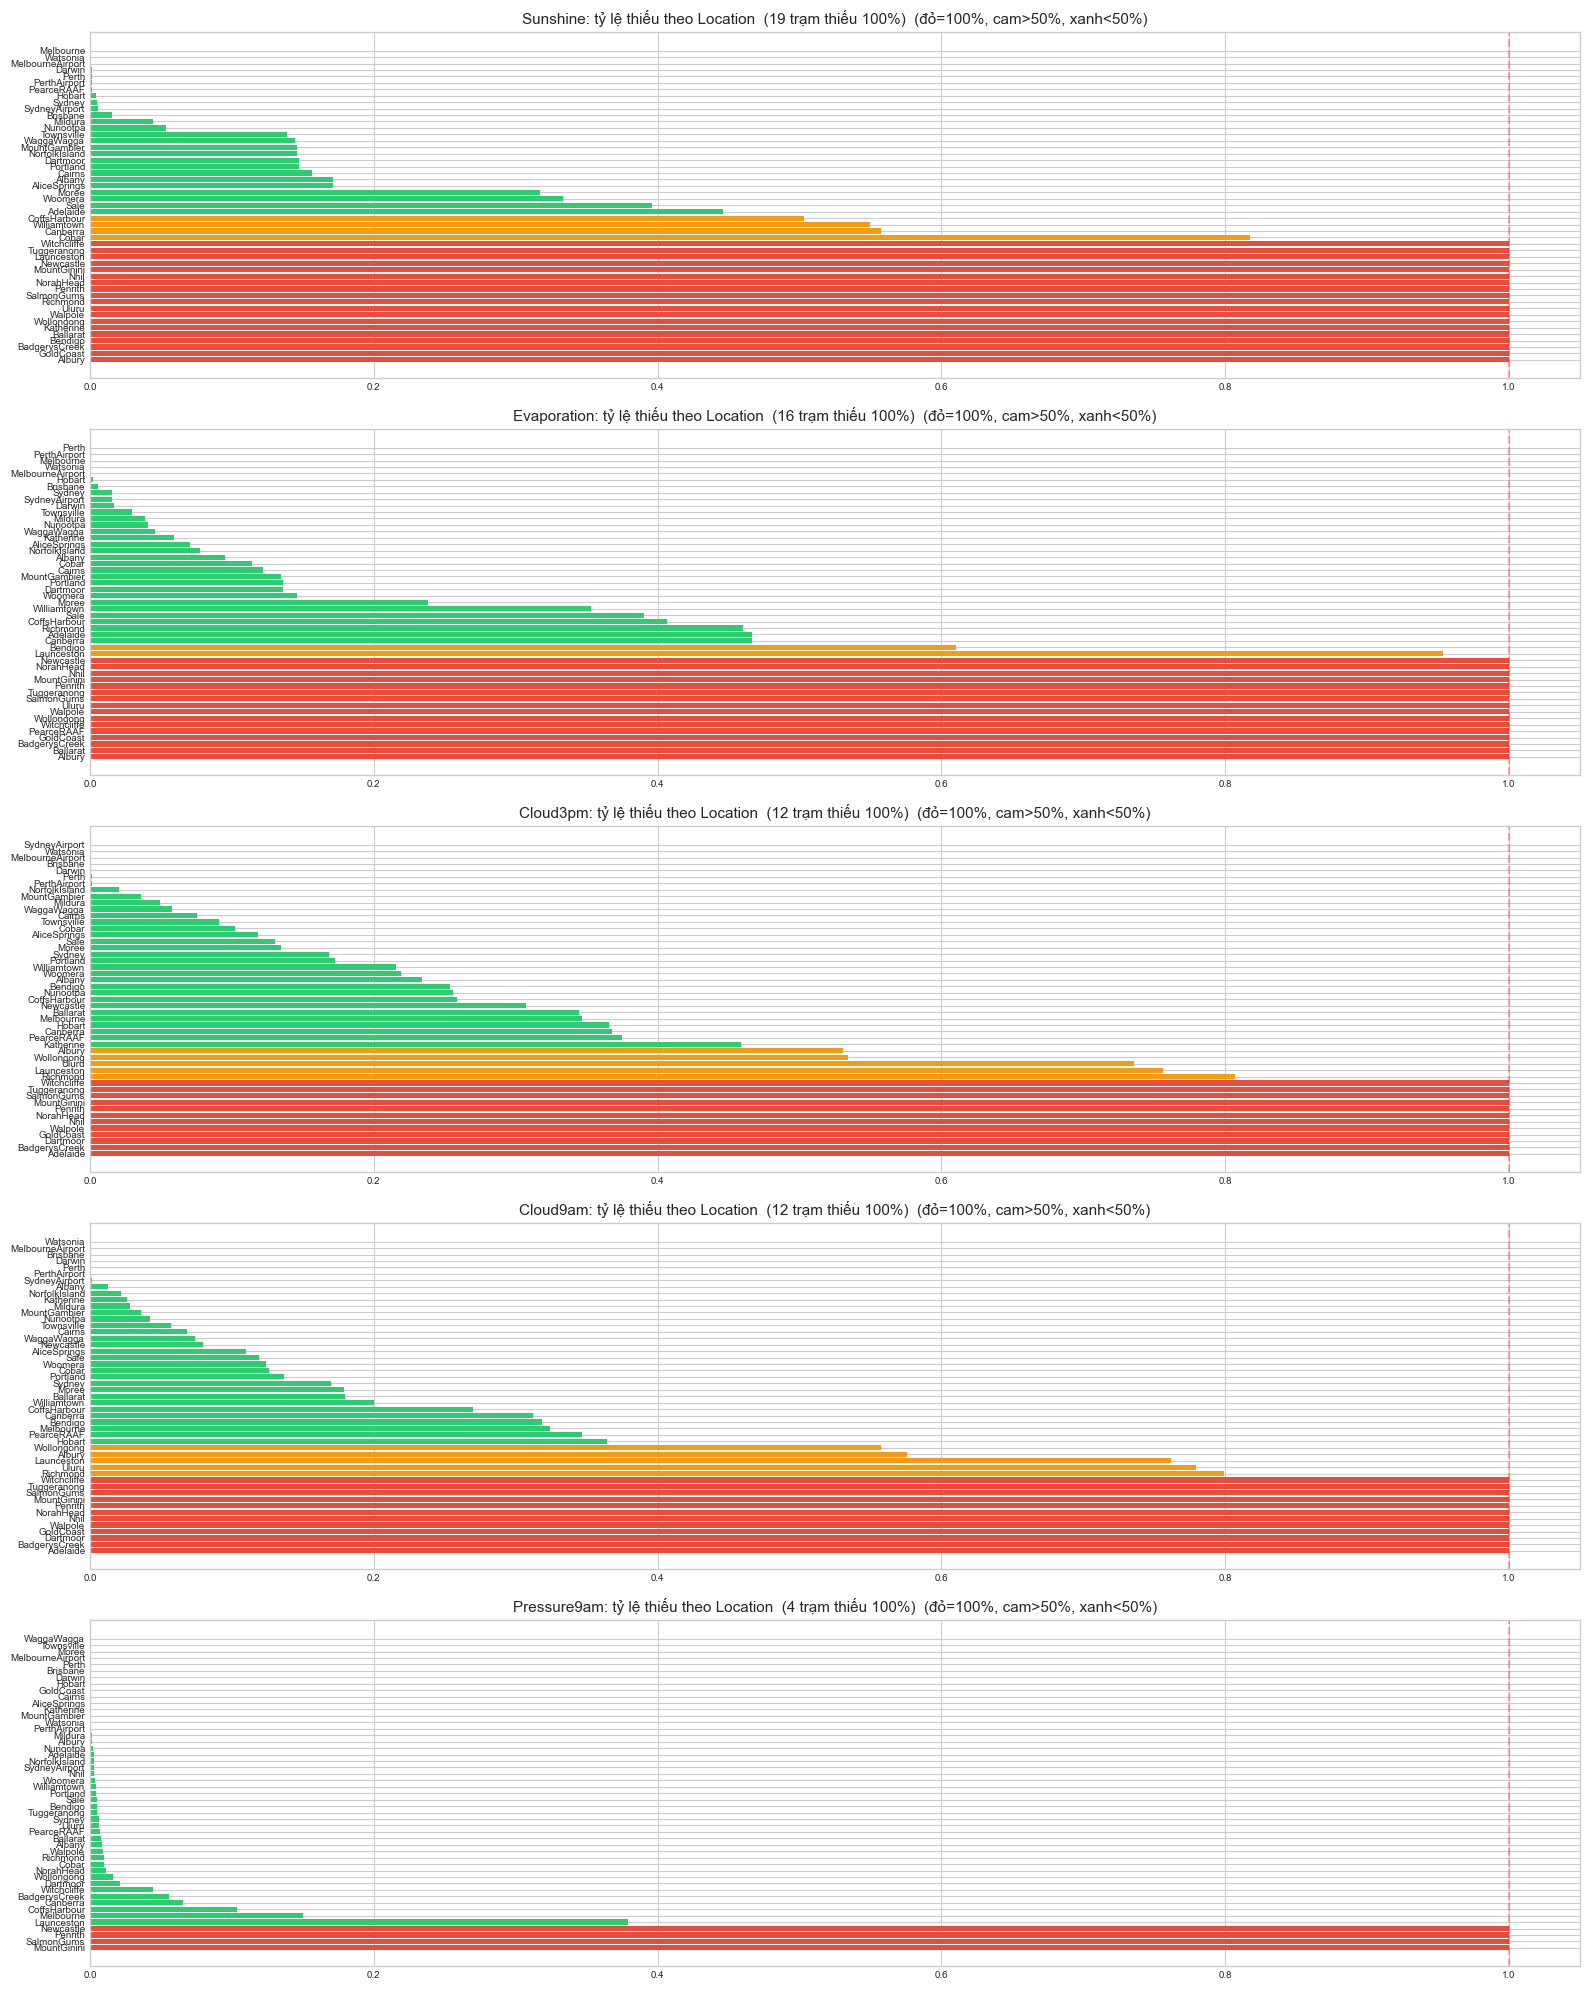

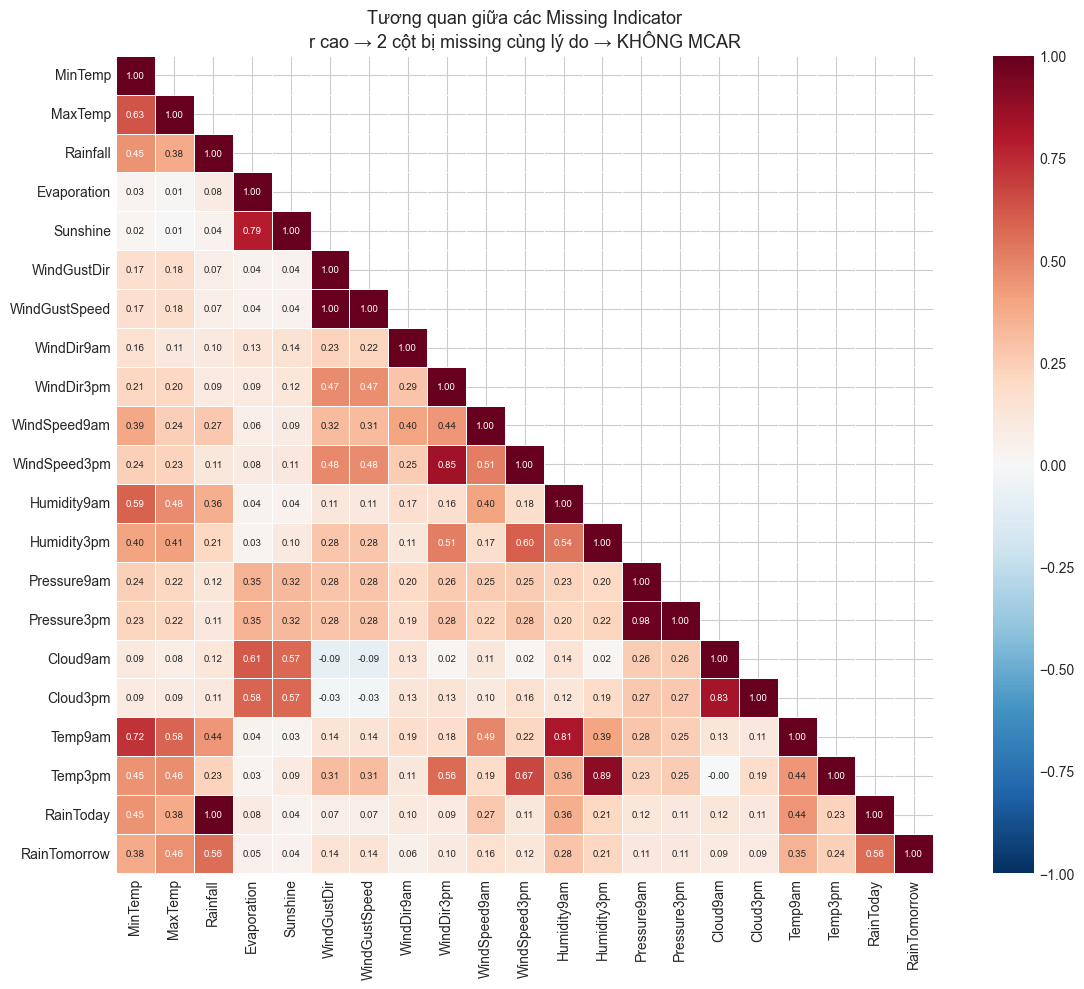


PHƯƠNG PHÁP SUY LUẬN ĐÃ SỬ DỤNG:
  ① Little's MCAR test: p ≈ 0 → BÁC BỎ MCAR toàn tập
  ② Tương quan Missing Indicator: cặp r > 0.9 → missing có hệ thống, KHÔNG MCAR
  ③ T-test nhóm missing vs non-missing: xác định biến nào giải thích được → MAR
  ④ Domain Knowledge + Location: phân loại MAR / MNAR bằng loại trừ

LƯU Ý: Không tồn tại kiểm định nào phân biệt MAR và MNAR tuyệt đối.
  Nhóm dùng phương pháp loại trừ: EDA giải thích được → MAR; không giải thích → MNAR.
  Chiến lược: giả định MAR → MICE/KNN Imputer. Rainfall (MNAR): median + flag biến.



In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# BẢNG TỔNG KẾT + BIỂU ĐỒ MINH HỌA
# ══════════════════════════════════════════════════════════════════════════════

result_df = pd.DataFrame(mechanism_results).sort_values('% thiếu', ascending=False)

# ── Bảng tổng kết ───────────────────────────────────────────────────────────
print('═' * 115)
print('  BẢNG TỔNG KẾT: Phân loại cơ chế thiếu dữ liệu (kết hợp 3 phương pháp)')
print('═' * 115)
print(f'{"Cột":<15} {"% thiếu":>7} {"Top r(indicator)":<28} {"T-test":>9} {"Trạm100%":>8} '
      f'{"Cơ chế":<18} {"Lý do"}')
print('─' * 115)
for _, r in result_df.iterrows():
    print(f'{r["Cột"]:<15} {r["% thiếu"]:>6.1f}% {r["Top r(indicator)"]:<28} '
          f'{r["T-test sig"]:>9} {r["Trạm 100%"]:>8} {r["Cơ chế"]:<18} {r["Lý do"]}')
print('═' * 115)

# ── Biểu đồ: Tỷ lệ thiếu theo Location (5 cột thiếu nhiều nhất) ───────────
top5 = result_df.head(5)['Cột'].tolist()
fig, axes = plt.subplots(len(top5), 1, figsize=(16, 4 * len(top5)))
for i, col in enumerate(top5):
    miss_rate = df.groupby('Location')[col].apply(lambda x: x.isna().mean()).sort_values(ascending=False)
    colors = ['#e74c3c' if v == 1.0 else ('#f39c12' if v > 0.5 else '#2ecc71') for v in miss_rate]
    n100 = (miss_rate == 1.0).sum()
    axes[i].barh(miss_rate.index, miss_rate.values, color=colors)
    axes[i].set_title(f'{col}: tỷ lệ thiếu theo Location  ({n100} trạm thiếu 100%)  '
                      f'(đỏ=100%, cam>50%, xanh<50%)', fontsize=11)
    axes[i].set_xlim(0, 1.05)
    axes[i].axvline(1.0, color='red', linestyle='--', alpha=0.3)
    axes[i].tick_params(labelsize=7)
plt.tight_layout()
plt.show()

# ── Heatmap tương quan Missing Indicator ─────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_miss, dtype=bool), k=1)
sns.heatmap(corr_miss, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.5,
            ax=ax2, square=True)
ax2.set_title('Tương quan giữa các Missing Indicator\n'
              'r cao → 2 cột bị missing cùng lý do → KHÔNG MCAR', fontsize=13)
plt.tight_layout()
plt.show()

print('''
PHƯƠNG PHÁP SUY LUẬN ĐÃ SỬ DỤNG:
  ① Little's MCAR test: p ≈ 0 → BÁC BỎ MCAR toàn tập
  ② Tương quan Missing Indicator: cặp r > 0.9 → missing có hệ thống, KHÔNG MCAR
  ③ T-test nhóm missing vs non-missing: xác định biến nào giải thích được → MAR
  ④ Domain Knowledge + Location: phân loại MAR / MNAR bằng loại trừ

LƯU Ý: Không tồn tại kiểm định nào phân biệt MAR và MNAR tuyệt đối.
  Nhóm dùng phương pháp loại trừ: EDA giải thích được → MAR; không giải thích → MNAR.
  Chiến lược: giả định MAR → MICE/KNN Imputer. Rainfall (MNAR): median + flag biến.
''')

**📌 Nhận xét — Phân tích giá trị thiếu (mục c)**

---

**1. Little's MCAR Test:** p-value $\approx 0 \ll \alpha = 0.05$ → **Bác bỏ H₀** \
→ Dữ liệu **KHÔNG phải MCAR** — việc thiếu dữ liệu KHÔNG hoàn toàn ngẫu nhiên.

**2. Phân loại cơ chế thiếu theo mức độ nghiêm trọng:**

| Mức | Thuộc tính | % thiếu | Cơ chế | Nguyên nhân |
|---|---|:---:|:---:|---|
| 🔴 Rất cao | `Sunshine`, `Evaporation` | 43–48% | **MAR** | Trạm đo không trang bị thiết bị |
| 🔴 Cao | `Cloud9am`, `Cloud3pm` | 38–40% | **MAR** | Phụ thuộc vào trạm (Location) |
| 🟠 Trung bình | `Pressure9am`, `Pressure3pm` | ~10% | **MAR** | Sensor áp suất ở một số trạm |
| 🟢 Thấp | `WindGustDir`, `Humidity3pm`, ... | 2–7% | **MAR** | Điều kiện thời tiết (lặng gió) |
| 🟢 Rất thấp | `MinTemp`, `MaxTemp`, `Temp9am/3pm` | 0.9–2.5% | **MAR** | Sensor glitch ngẫu nhiên có điều kiện |

> **Lưu ý:** Tất cả cột đều là **MAR** (Missing At Random) — không phát hiện MCAR hay MNAR.
> Chi-square test giữa pattern thiếu và `Location` đều có p < 0.001 → thiếu phụ thuộc địa lý.

**3. Hệ quả cho tiền xử lý:**
- ❌ Không dùng **Listwise Deletion** → mất tới ~48% dữ liệu nếu loại hàng có NA
- 🔵 Cột thiếu ≥ 20% (`Sunshine`, `Evaporation`, `Cloud*`): dùng **MICE** hoặc **kNN Imputation**
- 🟢 Cột thiếu < 10%: **Median** (số) / **Mode** (phân loại) là đủ
- Cơ chế **MAR** cho phép dùng **model-based imputation (MICE, kNN)** hiệu quả vì giá trị thiếu có thể được dự đoán từ các cột khác